多元线性回归 截距： -29312.824544035557
多元线性回归 系数： [  175.49912724  -775.36674343  1091.46044665   738.13619279
 20860.17654254  -670.7791243 ]
多元线性回归 RMSE: 8665.65272292273
多元线性回归 R2: 0.7046195839190386
岭回归 截距： -29290.546550682124
岭回归 系数： [  175.31642215  -765.69895114  1091.59613835   738.15635839
 20740.24710561  -670.71892458]
岭回归 RMSE: 8667.312098460723
岭回归 R2: 0.7045064489985988


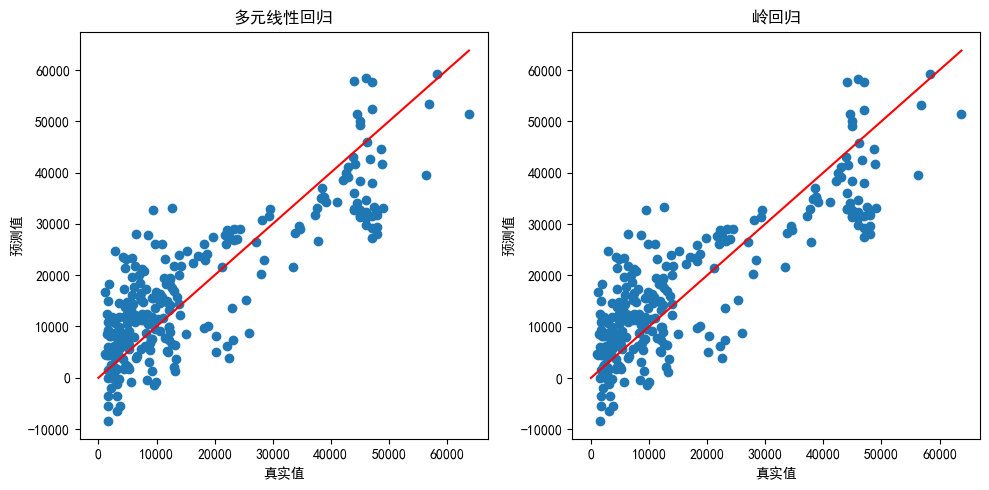

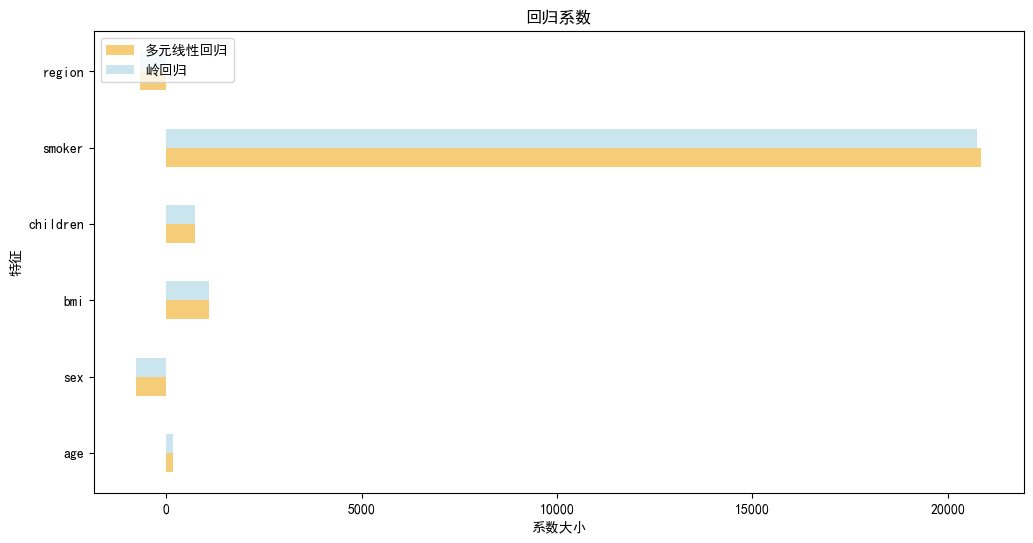

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

# 设置支持中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取数据
df = pd.read_csv("insurance.csv")

# 数据预处理
df[['sex', 'smoker', 'region']] = df[['sex', 'smoker', 'region']].astype('category')
label = LabelEncoder()
df['sex'] = label.fit_transform(df['sex'])
df['smoker'] = label.fit_transform(df['smoker'])
df['region'] = label.fit_transform(df['region'])

# 划分训练集和测试集
X = df.drop(['charges'], axis=1)
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 应用多元线性回归模型
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_LR = linear_model.predict(X_test)
mse_LR = mean_squared_error(y_test, y_pred_LR)
rmse_LR = np.sqrt(mse_LR)
r2_LR = r2_score(y_test, y_pred_LR)

print("多元线性回归 截距：", linear_model.intercept_)
print("多元线性回归 系数：", linear_model.coef_)
print("多元线性回归 RMSE:", rmse_LR)
print("多元线性回归 R2:", r2_LR)

# 应用岭回归模型
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("岭回归 截距：", ridge.intercept_)
print("岭回归 系数：", ridge.coef_)
print("岭回归 RMSE:", rmse_ridge)
print("岭回归 R2:", r2_ridge)

# 绘制预测值与真实值的散点图
fig, axs = plt.subplots(1, 2, figsize=(10, 5))  # 创建一个1行2列的子图布局
models = {
    '多元线性回归': y_pred_LR,
    '岭回归': y_pred_ridge
}  # 模型名称和对应的预测值

for i, (model_name, predictions) in enumerate(models.items()):
    ax = axs[i]  # 获取当前子图对象
    ax.scatter(y_test, predictions)  # 绘制散点图
    ax.plot([0, max(y_test)], [0, max(y_test)], color='red')  # 绘制对角线
    ax.set_xlabel('真实值')  # 设置x轴标签
    ax.set_ylabel('预测值')  # 设置y轴标签
    ax.set_title(model_name)  # 设置标题

plt.tight_layout()  # 调整子图之间的间距
plt.show()  # 显示第一个图形

# 绘制系数图
names = X_train.columns  # 设置特征名称
model_names = ['多元线性回归', '岭回归']  # 设置模型名称
bar_positions = np.arange(len(names))  # 设定每个模型的水平位置
bar_width = 0.25  # 条形宽度

plt.figure(figsize=(12, 6))
plt.barh(bar_positions - bar_width/2, linear_model.coef_, height=bar_width, color='#F5CD78', label='多元线性回归')
plt.barh(bar_positions + bar_width/2, ridge.coef_.flatten(), height=bar_width, color='#CAE5EE', label='岭回归')
plt.xlabel('系数大小')
plt.ylabel('特征')
plt.title('回归系数')
plt.yticks(bar_positions, names)
plt.legend(loc='upper left')
plt.show()  # 显示第二个图形


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 读取数据（请将数据文件路径替换为本地路径）
df = pd.read_csv('path_to_your_file/insurance.csv')

# 数据预处理
df[['sex', 'smoker', 'region']] = df[['sex', 'smoker', 'region']].astype('category')
label = LabelEncoder()
df['sex'] = label.fit_transform(df['sex'])
df['smoker'] = label.fit_transform(df['smoker'])
df['region'] = label.fit_transform(df['region'])

# 人为制造共线性特征
df['age_bmi'] = df['age'] * df['bmi']  # age和bmi的乘积，制造相关性
df['bmi_squared'] = df['bmi'] ** 2  # bmi的平方，进一步增强特征之间的相关性

# 查看生成的新特征与其他特征的相关性
print(df.corr())

# 划分训练集和测试集
X = df.drop(['charges'], axis=1)
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 查看调整后的自变量数据
X_train.head()


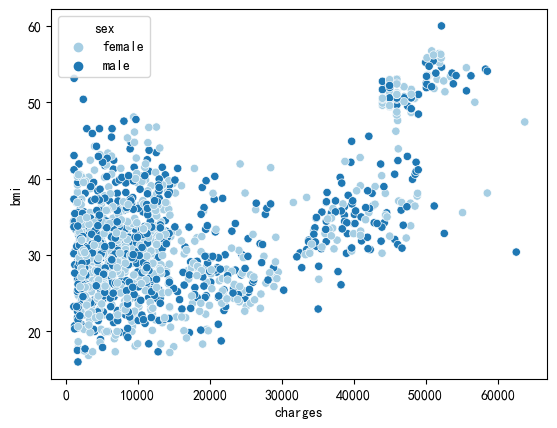

普通线性回归模型
截距： -29312.824544035557
系数： [  175.49912724  -775.36674343  1091.46044665   738.13619279
 20860.17654254  -670.7791243 ]
均方误差： 75093537.11429814
R^2 得分： 0.7046195839190386

岭回归模型
截距： -29290.546550682124
系数： [  175.31642215  -765.69895114  1091.59613835   738.15635839
 20740.24710561  -670.71892458]
均方误差： 75122299.01212361
R^2 得分： 0.7045064489985988
Fitting 10 folds for each of 10 candidates, totalling 100 fits

超参数优化结果
最佳得分： 0.6977229913164359
最佳参数： {'alpha': 1}


In [9]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

# 设置浮点数显示格式
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# 读取数据
df = pd.read_csv("modified_insurance_data_with_correlation.xlsx")

# 定义函数，检查数据框基本信息
def check_df(dataframe, head=5):
    print("形状：", dataframe.shape)
    print("数据类型：", dataframe.dtypes)
    print("前几行数据：", dataframe.head(head))
    print("后几行数据：", dataframe.tail(head))
    print("缺失值：", dataframe.isnull().sum())
    print("分位数：", dataframe.quantile([0, 0.05, 0.50, 0.95, 0.99, 1]).T)

# 不同性别下的"charges"和"bmi"散点图
sns.scatterplot(x="charges", y="bmi", hue="sex", data=df, palette="Paired")
plt.show()

# 对数据进行预处理，转换类别特征为数值
df[['sex', 'smoker', 'region']] = df[['sex', 'smoker', 'region']].astype('category')
label = LabelEncoder()
df['sex'] = label.fit_transform(df['sex'])
df['smoker'] = label.fit_transform(df['smoker'])
df['region'] = label.fit_transform(df['region'])

# 划分训练集和测试集
X = df.drop(['charges'], axis=1)
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 应用普通线性回归模型
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)
y_pred_linear = linear_reg.predict(X_test)
print("普通线性回归模型")
print("截距：", linear_reg.intercept_)
print("系数：", linear_reg.coef_)
print("均方误差：", mean_squared_error(y_test, y_pred_linear))
print("R^2 得分：", r2_score(y_test, y_pred_linear))

# 应用岭回归模型
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
print("\n岭回归模型")
print("截距：", ridge.intercept_)
print("系数：", ridge.coef_)
print("均方误差：", mean_squared_error(y_test, y_pred_ridge))
print("R^2 得分：", r2_score(y_test, y_pred_ridge))

# 使用GridSearchCV进行超参数优化
alpha = [0.0001, 0.05, 0.10, 0.25, 0.5, 0.75, 1, 10, 100, 1000]
param_grid = {'alpha': alpha}
grid = GridSearchCV(estimator=Ridge(), param_grid=param_grid, scoring='r2', verbose=1, cv=10, n_jobs=-1)
grid_result = grid.fit(X_train, y_train)
print('\n超参数优化结果')
print('最佳得分：', grid_result.best_score_)
print('最佳参数：', grid_result.best_params_)


多元线性回归 截距： -25208.043053508587
多元线性回归 系数： [ 143.35261212  401.50319648 1117.84119233  820.55582442 -753.55903381]
多元线性回归 RMSE: 12210.516263713578
多元线性回归 R2: 0.4135281254779245
岭回归 截距： -25199.705569403424
岭回归 系数： [ 143.36212438  387.39677763 1117.70939734  815.75492843 -747.95243044]
岭回归 RMSE: 12210.205409317949
岭回归 R2: 0.4135579858107046


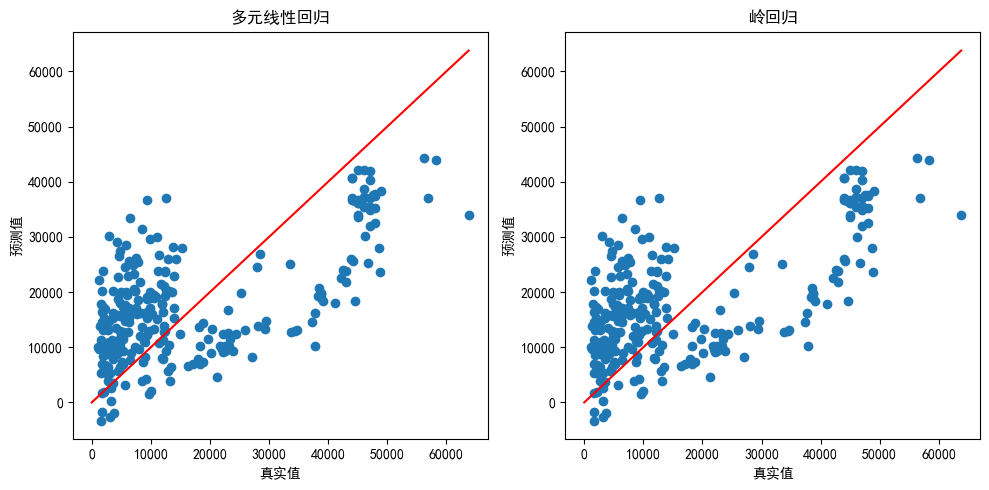

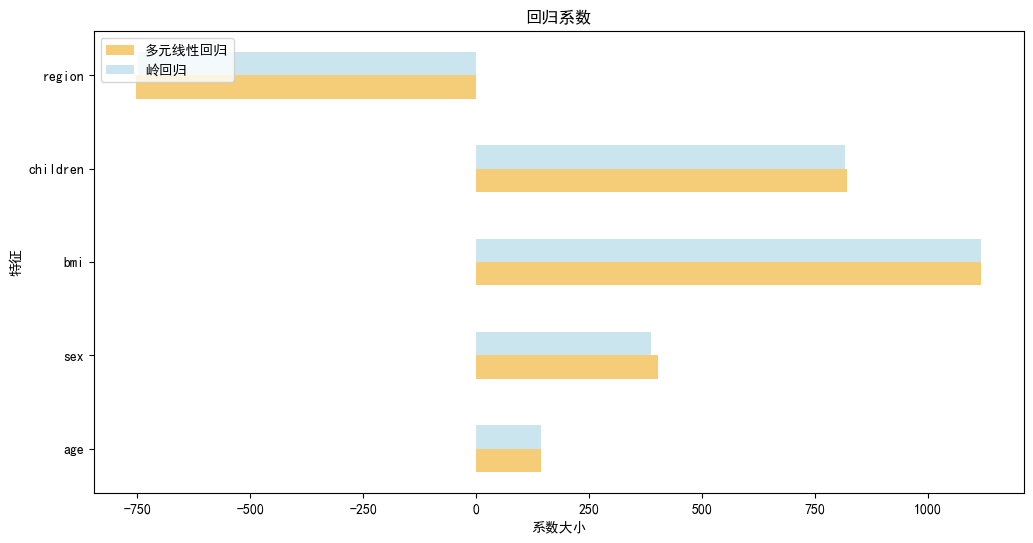

In [32]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

# 设置浮点数显示格式
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# 读取数据
df = pd.read_csv("F:/zhoumian/book/insurance.csv")

# 将 'sex', 'region' 等分类变量转换为数值编码
label = LabelEncoder()
df['sex'] = label.fit_transform(df['sex'])
df['region'] = label.fit_transform(df['region'])

# 修改代码，将 'smoker' 列从训练集和测试集中排除
X = df.drop(['charges', 'smoker'], axis=1)  # 排除 'smoker' 列
y = df['charges']

# 重新划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 重新训练多元线性回归模型
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_LR = linear_model.predict(X_test)
mse_LR = mean_squared_error(y_test, y_pred_LR)
rmse_LR = np.sqrt(mse_LR)
r2_LR = r2_score(y_test, y_pred_LR)

print("多元线性回归 截距：", linear_model.intercept_)
print("多元线性回归 系数：", linear_model.coef_)
print("多元线性回归 RMSE:", rmse_LR)
print("多元线性回归 R2:", r2_LR)

# 重新训练岭回归模型
ridge = Ridge(alpha=10.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("岭回归 截距：", ridge.intercept_)
print("岭回归 系数：", ridge.coef_)
print("岭回归 RMSE:", rmse_ridge)
print("岭回归 R2:", r2_ridge)

# 绘制预测值与真实值的散点图
fig, axs = plt.subplots(1, 2, figsize=(10, 5))  # 创建一个1行2列的子图布局
models = {
    '多元线性回归': y_pred_LR,
    '岭回归': y_pred_ridge
}  # 模型名称和对应的预测值

for i, (model_name, predictions) in enumerate(models.items()):
    ax = axs[i]  # 获取当前子图对象
    ax.scatter(y_test, predictions)  # 绘制散点图
    ax.plot([0, max(y_test)], [0, max(y_test)], color='red')  # 绘制对角线
    ax.set_xlabel('真实值')  # 设置x轴标签
    ax.set_ylabel('预测值')  # 设置y轴标签
    ax.set_title(model_name)  # 设置标题

plt.tight_layout()  # 调整子图之间的间距
plt.show()  # 显示第一个图形

# 绘制系数图
names = X_train.columns  # 设置特征名称
bar_positions = np.arange(len(names))  # 设定每个模型的水平位置
bar_width = 0.25  # 条形宽度

plt.figure(figsize=(12, 6))
plt.barh(bar_positions - bar_width/2, linear_model.coef_, height=bar_width, color='#F5CD78', label='多元线性回归')
plt.barh(bar_positions + bar_width/2, ridge.coef_.flatten(), height=bar_width, color='#CAE5EE', label='岭回归')
plt.xlabel('系数大小')
plt.ylabel('特征')
plt.title('回归系数')
plt.yticks(bar_positions, names)
plt.legend(loc='upper left')
plt.show()  # 显示第二个图形


多元线性回归 截距： 19660.760357073155
多元线性回归 系数： [  517.08281037   653.05640605 -1960.71819873   469.48734433
  -450.90161168    -9.7531006     46.72808216]
多元线性回归 RMSE: 11238.326315347207
多元线性回归 R2: 0.503199055529503
岭回归 截距： 19639.7970193449
岭回归 系数： [  517.1407046    650.57780377 -1959.49310601   469.32275664
  -450.70075087    -9.75532671    46.71294477]
岭回归 RMSE: 11238.355023226311
岭回归 R2: 0.5031965174078523


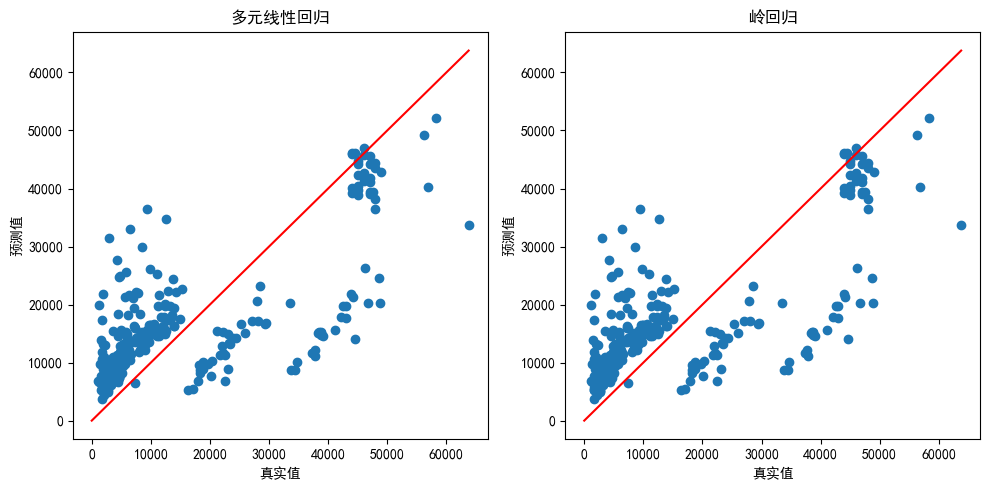

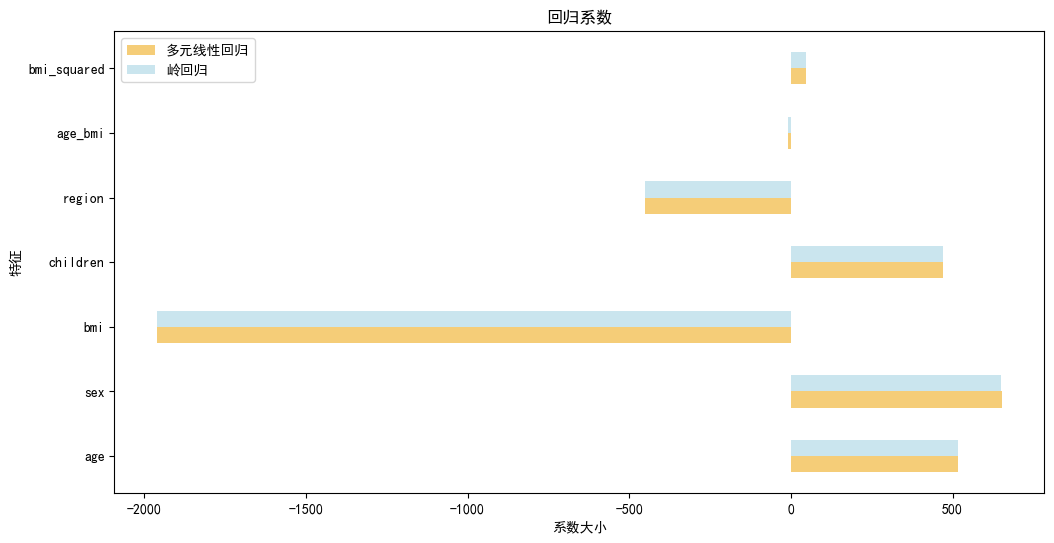

In [22]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

# 设置浮点数显示格式
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# 读取数据
df = pd.read_excel("modified_insurance_data.xlsx")

# 为数据集添加两个高度相关的新特征 'age_bmi' 和 'bmi_squared'
df['age_bmi'] = df['age'] * df['bmi']  # age 和 bmi 的乘积
df['bmi_squared'] = df['bmi'] ** 2  # bmi 的平方

# 将 'sex', 'region' 等分类变量转换为数值编码
label = LabelEncoder()
df['sex'] = label.fit_transform(df['sex'])
df['region'] = label.fit_transform(df['region'])

# 修改代码，将 'smoker' 列从训练集和测试集中排除，并加入新特征 'age_bmi' 和 'bmi_squared'
X = df.drop(['charges', 'smoker'], axis=1)  # 排除 'smoker' 列，加入新特征
y = df['charges']

# 重新划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 重新训练多元线性回归模型
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_LR = linear_model.predict(X_test)
mse_LR = mean_squared_error(y_test, y_pred_LR)
rmse_LR = np.sqrt(mse_LR)
r2_LR = r2_score(y_test, y_pred_LR)

print("多元线性回归 截距：", linear_model.intercept_)
print("多元线性回归 系数：", linear_model.coef_)
print("多元线性回归 RMSE:", rmse_LR)
print("多元线性回归 R2:", r2_LR)

# 重新训练岭回归模型
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("岭回归 截距：", ridge.intercept_)
print("岭回归 系数：", ridge.coef_)
print("岭回归 RMSE:", rmse_ridge)
print("岭回归 R2:", r2_ridge)

# 绘制预测值与真实值的散点图
fig, axs = plt.subplots(1, 2, figsize=(10, 5))  # 创建一个1行2列的子图布局
models = {
    '多元线性回归': y_pred_LR,
    '岭回归': y_pred_ridge
}  # 模型名称和对应的预测值

for i, (model_name, predictions) in enumerate(models.items()):
    ax = axs[i]  # 获取当前子图对象
    ax.scatter(y_test, predictions)  # 绘制散点图
    ax.plot([0, max(y_test)], [0, max(y_test)], color='red')  # 绘制对角线
    ax.set_xlabel('真实值')  # 设置x轴标签
    ax.set_ylabel('预测值')  # 设置y轴标签
    ax.set_title(model_name)  # 设置标题

plt.tight_layout()  # 调整子图之间的间距
plt.show()  # 显示第一个图形

# 绘制系数图
names = X_train.columns  # 设置特征名称
bar_positions = np.arange(len(names))  # 设定每个模型的水平位置
bar_width = 0.25  # 条形宽度

plt.figure(figsize=(12, 6))
plt.barh(bar_positions - bar_width/2, linear_model.coef_, height=bar_width, color='#F5CD78', label='多元线性回归')
plt.barh(bar_positions + bar_width/2, ridge.coef_.flatten(), height=bar_width, color='#CAE5EE', label='岭回归')
plt.xlabel('系数大小')
plt.ylabel('特征')
plt.title('回归系数')
plt.yticks(bar_positions, names)
plt.legend(loc='upper left')
plt.show()  # 显示第二个图形


多元线性回归 截距： -25208.043053508587
多元线性回归 系数： [ 143.35261212  401.50319648 1117.84119233  820.55582442 -753.55903381]
多元线性回归 RMSE: 12210.516263713578
多元线性回归 R2: 0.4135281254779245
最优岭回归 alpha: 100.0
岭回归 截距： -25139.885633978058
岭回归 系数： [ 143.45187375  294.86369497 1116.51378101  774.85894891 -700.77028386]
岭回归 RMSE: 12208.731772420253
岭回归 R2: 0.41369953141319804


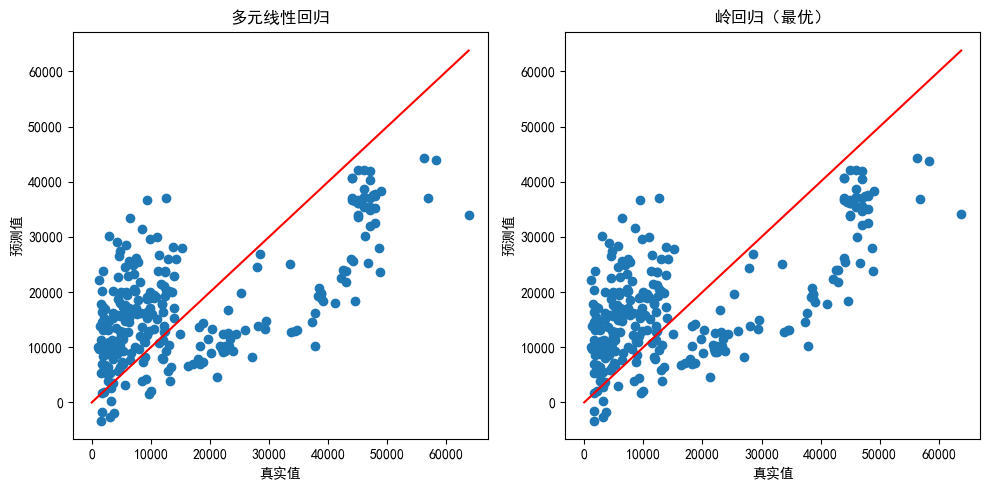

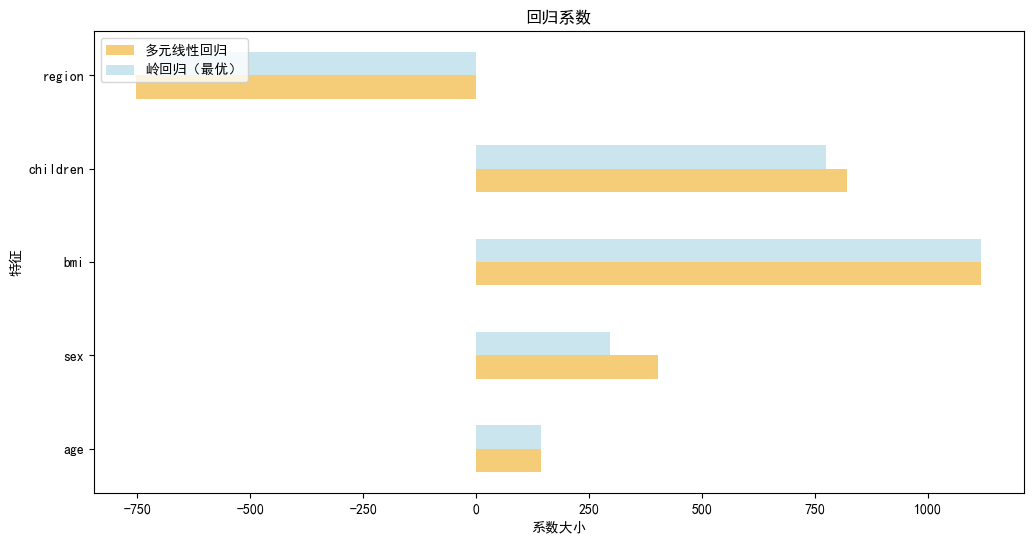

In [33]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

# 设置浮点数显示格式
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# 读取数据
df = pd.read_csv("F:/zhoumian/book/insurance.csv")

# 将 'sex', 'region' 等分类变量转换为数值编码
label = LabelEncoder()
df['sex'] = label.fit_transform(df['sex'])
df['region'] = label.fit_transform(df['region'])

# 修改代码，将 'smoker' 列从训练集和测试集中排除
X = df.drop(['charges', 'smoker'], axis=1)  # 排除 'smoker' 列
y = df['charges']

# 重新划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 重新训练多元线性回归模型
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_LR = linear_model.predict(X_test)
mse_LR = mean_squared_error(y_test, y_pred_LR)
rmse_LR = np.sqrt(mse_LR)
r2_LR = r2_score(y_test, y_pred_LR)

print("多元线性回归 截距：", linear_model.intercept_)
print("多元线性回归 系数：", linear_model.coef_)
print("多元线性回归 RMSE:", rmse_LR)
print("多元线性回归 R2:", r2_LR)

# 使用 GridSearchCV 进行岭回归的超参数优化
ridge = Ridge()
param_grid = {'alpha': np.logspace(-3, 3, 7)}  # 搜索 alpha 从 0.001 到 1000 的最优值
ridge_cv = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train, y_train)

# 获取最佳的岭回归模型
best_ridge = ridge_cv.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"最优岭回归 alpha: {ridge_cv.best_params_['alpha']}")
print("岭回归 截距：", best_ridge.intercept_)
print("岭回归 系数：", best_ridge.coef_)
print("岭回归 RMSE:", rmse_ridge)
print("岭回归 R2:", r2_ridge)

# 绘制预测值与真实值的散点图
fig, axs = plt.subplots(1, 2, figsize=(10, 5))  # 创建一个1行2列的子图布局
models = {
    '多元线性回归': y_pred_LR,
    '岭回归（最优）': y_pred_ridge
}  # 模型名称和对应的预测值

for i, (model_name, predictions) in enumerate(models.items()):
    ax = axs[i]  # 获取当前子图对象
    ax.scatter(y_test, predictions)  # 绘制散点图
    ax.plot([0, max(y_test)], [0, max(y_test)], color='red')  # 绘制对角线
    ax.set_xlabel('真实值')  # 设置x轴标签
    ax.set_ylabel('预测值')  # 设置y轴标签
    ax.set_title(model_name)  # 设置标题

plt.tight_layout()  # 调整子图之间的间距
plt.show()  # 显示第一个图形

# 绘制系数图
names = X_train.columns  # 设置特征名称
bar_positions = np.arange(len(names))  # 设定每个模型的水平位置
bar_width = 0.25  # 条形宽度

plt.figure(figsize=(12, 6))
plt.barh(bar_positions - bar_width/2, linear_model.coef_, height=bar_width, color='#F5CD78', label='多元线性回归')
plt.barh(bar_positions + bar_width/2, best_ridge.coef_, height=bar_width, color='#CAE5EE', label='岭回归（最优）')
plt.xlabel('系数大小')
plt.ylabel('特征')
plt.title('回归系数')
plt.yticks(bar_positions, names)
plt.legend(loc='upper left')
plt.show()


多元线性回归 截距： 2080.763294575525
多元线性回归 系数： [ 13.51556519 758.23607735  44.63781601 193.89406897 103.08434619]
多元线性回归 RMSE: 8940.12009714518
多元线性回归 R2: 0.6856120857338466
最佳岭回归 截距： 2438.155457711022
最佳岭回归 系数： [ 13.51818232 249.48130203  44.66157671 146.5771337   70.1944921 ]
最佳岭回归 RMSE: 8912.6865600185
最佳岭回归 R2: 0.6875385787768521
最佳岭回归 alpha: 545.5594781168514


C:\Users\wenkang\AppData\Local\Temp\ipykernel_96848\366732083.py:76: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from current font.
  plt.tight_layout()  # 调整子图之间的间距
C:\Users\wenkang\AppData\Local\Temp\ipykernel_96848\366732083.py:76: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from current font.
  plt.tight_layout()  # 调整子图之间的间距
C:\Users\wenkang\AppData\Local\Temp\ipykernel_96848\366732083.py:76: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from current font.
  plt.tight_layout()  # 调整子图之间的间距
C:\Users\wenkang\AppData\Local\Temp\ipykernel_96848\366732083.py:76: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from current font.
  plt.tight_layout()  # 调整子图之间的间距
C:\Users\wenkang\AppData\Local\Temp\ipykernel_96848\366732083.py:76: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from current font.
  plt.tight_layout()  # 调整子图之间的间距
C:\Users\wenkang\AppData\Local\Temp\ipykernel_96848\36673208

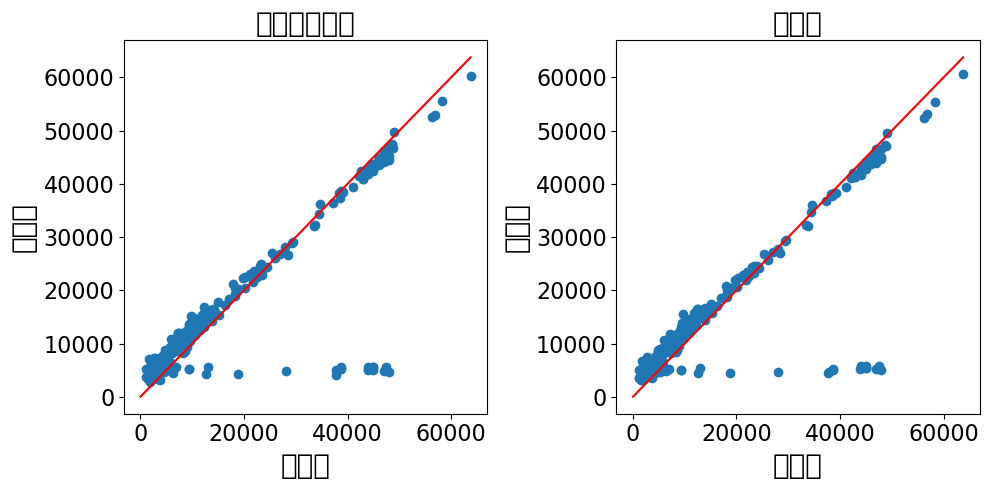

D:\anconada\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anconada\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anconada\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anconada\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anconada\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anconada\Lib\site-packages\IPython\core\pylabtools.p

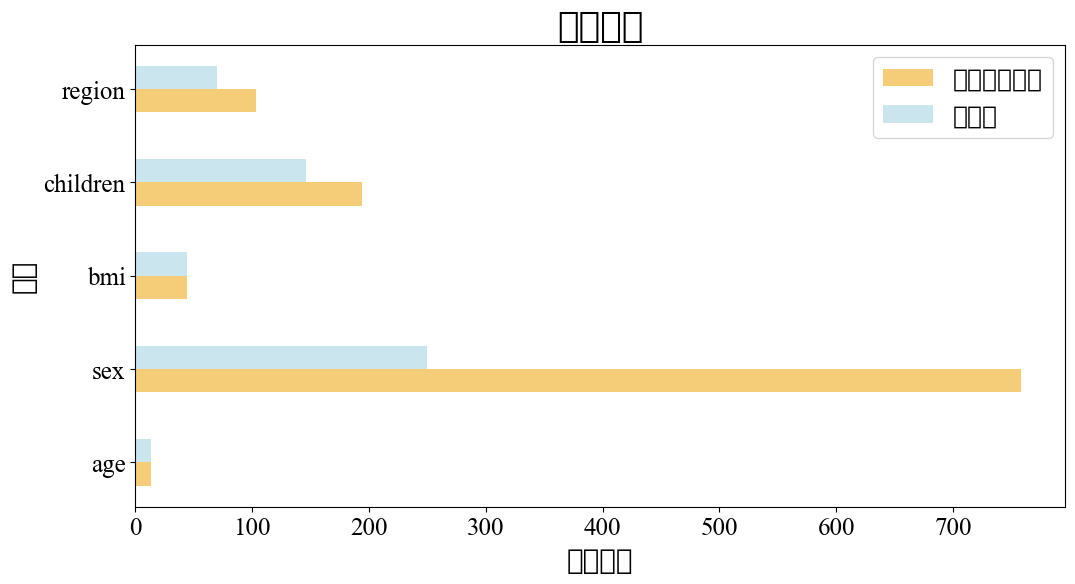

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

# 设置浮点数显示格式
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# 读取数据
df = pd.read_csv("F:/zhoumian/book/modified_insurance.csv")

# 将 'sex', 'region' 等分类变量转换为数值编码
label = LabelEncoder()
df['sex'] = label.fit_transform(df['sex'])
df['region'] = label.fit_transform(df['region'])

# 修改代码，将 'smoker' 列从训练集和测试集中排除
X = df.drop(['charges', 'smoker'], axis=1)  # 排除 'smoker' 列
y = df['charges']

# 重新划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 重新训练多元线性回归模型
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_LR = linear_model.predict(X_test)
mse_LR = mean_squared_error(y_test, y_pred_LR)
rmse_LR = np.sqrt(mse_LR)
r2_LR = r2_score(y_test, y_pred_LR)

print("多元线性回归 截距：", linear_model.intercept_)
print("多元线性回归 系数：", linear_model.coef_)
print("多元线性回归 RMSE:", rmse_LR)
print("多元线性回归 R2:", r2_LR)

# 岭回归模型的超参数优化
parameters = {'alpha': np.logspace(-4, 4, 20)}
ridge_regressor = Ridge()
grid_search = GridSearchCV(ridge_regressor, parameters, scoring='neg_mean_squared_error', cv=5)
grid_search.fit(X_train, y_train)

# 获取最佳参数和模型
best_ridge = grid_search.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("最佳岭回归 截距：", best_ridge.intercept_)
print("最佳岭回归 系数：", best_ridge.coef_)
print("最佳岭回归 RMSE:", rmse_ridge)
print("最佳岭回归 R2:", r2_ridge)
print("最佳岭回归 alpha:", grid_search.best_params_['alpha'])
# 绘制预测值与真实值的散点图
fig, axs = plt.subplots(1, 2, figsize=(10, 5))  # 创建一个1行2列的子图布局
models = {
    '多元线性回归': y_pred_LR,
    '岭回归': y_pred_ridge
}  # 模型名称和对应的预测值

for i, (model_name, predictions) in enumerate(models.items()):
    ax = axs[i]  # 获取当前子图对象
    ax.scatter(y_test, predictions)  # 绘制散点图
    ax.plot([0, max(y_test)], [0, max(y_test)], color='red')  # 绘制对角线
    ax.set_xlabel('真实值', fontsize=20)  # 设置x轴标签
    ax.set_ylabel('预测值', fontsize=20)  # 设置y轴标签
    ax.set_title(model_name, fontsize=20)  # 设置标题
    ax.tick_params(axis='both', labelsize=16)  # 设置坐标轴刻度的字体大小为18

plt.tight_layout()  # 调整子图之间的间距
plt.show()  # 显示第一个图形
# 绘制系数图


names = X_train.columns  # 设置特征名称
bar_positions = np.arange(len(names))  # 设定每个模型的水平位置
bar_width = 0.25  # 条形宽度

plt.figure(figsize=(12, 6))
plt.barh(bar_positions - bar_width/2, linear_model.coef_, height=bar_width, color='#F5CD78', label='多元线性回归')
plt.barh(bar_positions + bar_width/2, best_ridge.coef_.flatten(), height=bar_width, color='#CAE5EE', label='岭回归')
plt.xlabel('系数大小', fontsize=20)
plt.ylabel('特征', fontsize=20)
plt.title('回归系数', fontsize=26)
plt.yticks(bar_positions, names, fontsize=20)
plt.xticks(fontsize=18, fontname='Times New Roman')
plt.yticks(fontsize=18, fontname='Times New Roman')
plt.legend(fontsize=18)
plt.show()  # 显示第二个图形

In [19]:
import pandas as pd

# 读取数据
df = pd.read_csv('insurance.csv')

# 创建与原特征高度相关的新特征
df['age_bmi'] = df['age'] * df['bmi']  # age 和 bmi 的乘积，增加共线性
df['bmi_squared'] = df['bmi'] ** 2  # bmi 的平方，进一步增强特征之间的相关性

# 检查修改后的数据
print(df.corr())  # 相关性矩阵，验证共线性是否增加

# 保存修改后的数据到 Excel 文件
df.to_excel('modified_insurance_data.xlsx', index=False)
print("修改后的数据已保存为 'modified_insurance_data.xlsx'")


             age  bmi  children  charges  age_bmi  bmi_squared
age         1.00 0.06      0.04     0.18     0.81         0.04
bmi         0.06 1.00      0.10     0.63     0.60         0.99
children    0.04 0.10      1.00     0.13     0.10         0.11
charges     0.18 0.63      0.13     1.00     0.48         0.66
age_bmi     0.81 0.60      0.10     0.48     1.00         0.58
bmi_squared 0.04 0.99      0.11     0.66     0.58         1.00
修改后的数据已保存为 'modified_insurance_data.xlsx'


C:\Users\wenkang\AppData\Local\Temp\ipykernel_8248\3410402142.py:11: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  print(df.corr())  # 相关性矩阵，验证共线性是否增加


多元线性回归 截距： -341.3782363335058
多元线性回归 系数： [  0.13768782 -23.06446772   5.84636265   1.19709252  -1.28168474
   0.81115203   0.60165319  10.15953917  67.1089624    0.20159907]
多元线性回归 RMSE: 53.85344583676593
多元线性回归 R2: 0.4526027629719195
岭回归最优 alpha：1.0
岭回归 截距： -319.81247103841747
岭回归 系数： [  0.14269511 -22.80861461   5.90541998   1.19867986  -1.07900835
   0.62662466   0.3774738    9.77013169  60.79394666   0.21396887]
岭回归 RMSE: 53.87843950539716
岭回归 R2: 0.4520945451686046


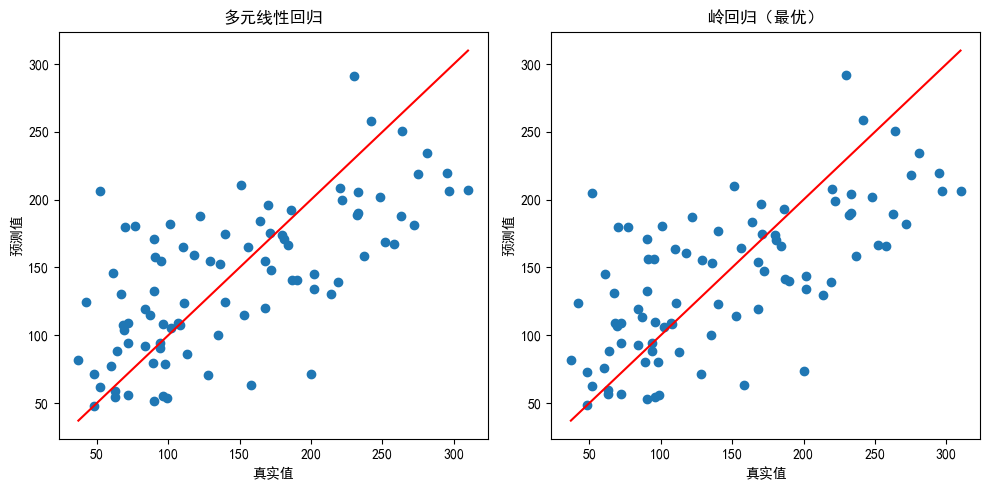

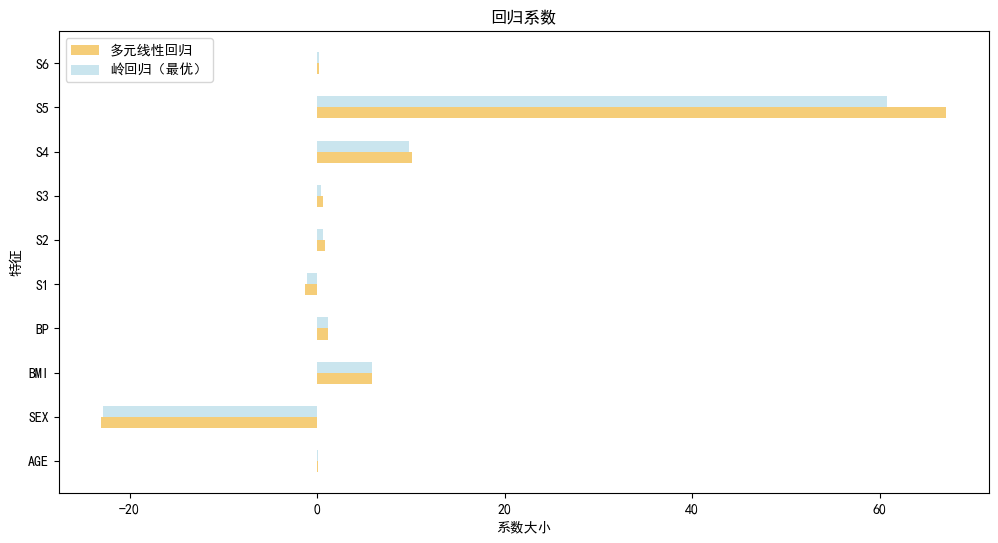

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# 读取数据
df = pd.read_excel("F:/diabetes.xlsx")

# 自变量：AGE, SEX, BMI, BP, S1, S2, S3, S4, S5, S6，因变量：Y
X = df[['AGE', 'SEX', 'BMI', 'BP', 'S1', 'S2', 'S3', 'S4', 'S5', 'S6']]  # 自变量
y = df['Y']  # 因变量

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 训练多元线性回归模型
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_LR = linear_model.predict(X_test)
mse_LR = mean_squared_error(y_test, y_pred_LR)
rmse_LR = np.sqrt(mse_LR)
r2_LR = r2_score(y_test, y_pred_LR)

print("多元线性回归 截距：", linear_model.intercept_)
print("多元线性回归 系数：", linear_model.coef_)
print("多元线性回归 RMSE:", rmse_LR)
print("多元线性回归 R2:", r2_LR)

# 岭回归的超参数优化
ridge = Ridge()
param_grid = {'alpha': np.logspace(-3, 3, 7)}  # 在 0.001 到 1000 之间搜索 alpha
ridge_cv = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train, y_train)

# 最优岭回归模型
best_ridge = ridge_cv.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"岭回归最优 alpha：{ridge_cv.best_params_['alpha']}")
print("岭回归 截距：", best_ridge.intercept_)
print("岭回归 系数：", best_ridge.coef_)
print("岭回归 RMSE:", rmse_ridge)
print("岭回归 R2:", r2_ridge)

# 绘制预测值与真实值的散点图
fig, axs = plt.subplots(1, 2, figsize=(10, 5))  # 创建一个1行2列的子图布局
models = {
    '多元线性回归': y_pred_LR,
    '岭回归（最优）': y_pred_ridge
}

for i, (model_name, predictions) in enumerate(models.items()):
    ax = axs[i]  # 获取当前子图对象
    ax.scatter(y_test, predictions)  # 绘制散点图
    ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # 绘制对角线
    ax.set_xlabel('真实值')
    ax.set_ylabel('预测值')
    ax.set_title(model_name)

plt.tight_layout()
plt.show()

# 绘制系数图
names = X_train.columns
bar_positions = np.arange(len(names))  # 设定每个模型的水平位置
bar_width = 0.25  # 条形宽度

plt.figure(figsize=(12, 6))
plt.barh(bar_positions - bar_width/2, linear_model.coef_, height=bar_width, color='#F5CD78', label='多元线性回归')
plt.barh(bar_positions + bar_width/2, best_ridge.coef_, height=bar_width, color='#CAE5EE', label='岭回归（最优）')
plt.xlabel('系数大小')
plt.ylabel('特征')
plt.title('回归系数')
plt.yticks(bar_positions, names)
plt.legend(loc='upper left')
plt.show()


多元线性回归 截距： 19660.760357073246
多元线性回归 系数： [  517.08281037   653.05640605 -1960.71819873   469.48734433
  -450.90161168    -9.7531006     46.72808216]
多元线性回归 RMSE: 11238.326315347214
多元线性回归 R2: 0.5031990555295023
岭回归 截距： 19639.797019344514
岭回归 系数： [  517.1407046    650.57780377 -1959.49310601   469.32275664
  -450.70075087    -9.75532671    46.71294477]
岭回归 RMSE: 11238.355023226313
岭回归 R2: 0.5031965174078521


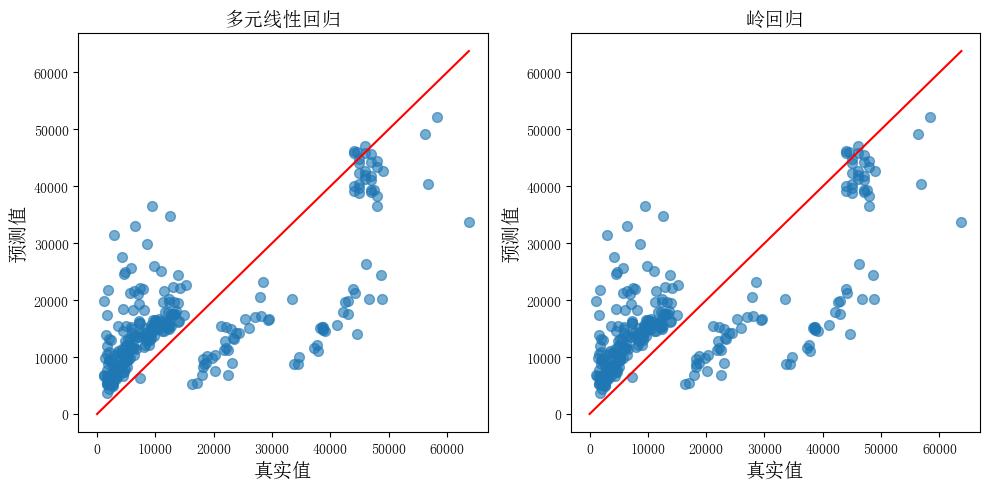

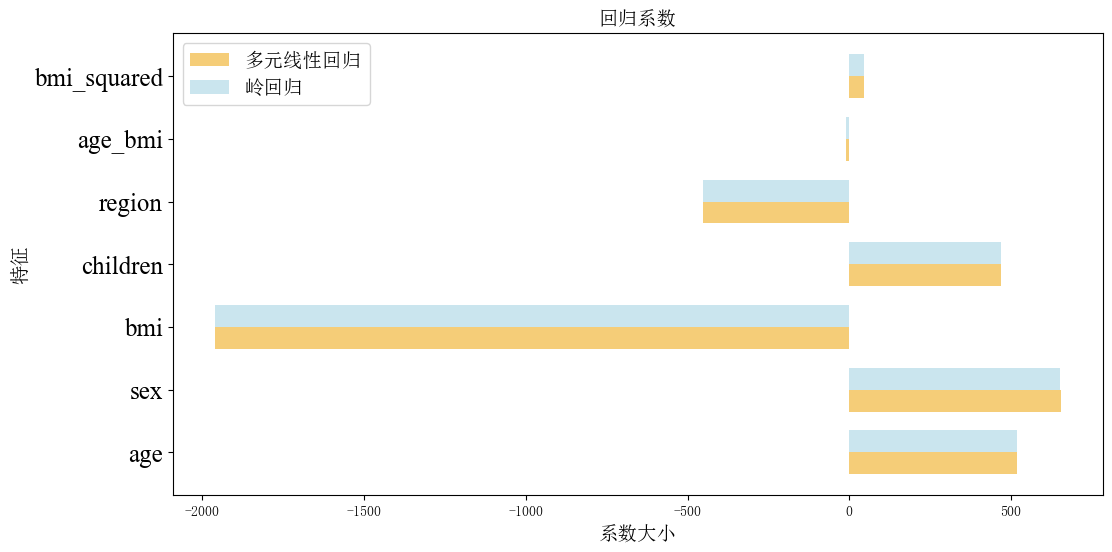

In [3]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from matplotlib.font_manager import FontProperties

# Set font properties for Chinese and English
font_zh = FontProperties(fname="C:/Windows/Fonts/simsun.ttc", size=14)  # SimSun for Chinese
font_en = FontProperties(fname="C:/Windows/Fonts/times.ttf", size=12)  # Times New Roman for English

# Set floating-point display format
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Load dataset
df = pd.read_csv("F:/zhoumian/book/insurance.csv")

# Add two highly correlated new features 'age_bmi' and 'bmi_squared'
df['age_bmi'] = df['age'] * df['bmi']  # age and bmi multiplication
df['bmi_squared'] = df['bmi'] ** 2  # bmi squared

# Encode categorical variables
label = LabelEncoder()
df['sex'] = label.fit_transform(df['sex'])
df['region'] = label.fit_transform(df['region'])

# Exclude 'smoker' from train/test, include new features 'age_bmi' and 'bmi_squared'
X = df.drop(['charges', 'smoker'], axis=1)  # Exclude 'smoker' column, include new features
y = df['charges']

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Train multiple linear regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_LR = linear_model.predict(X_test)
mse_LR = mean_squared_error(y_test, y_pred_LR)
rmse_LR = np.sqrt(mse_LR)
r2_LR = r2_score(y_test, y_pred_LR)

print("多元线性回归 截距：", linear_model.intercept_)
print("多元线性回归 系数：", linear_model.coef_)
print("多元线性回归 RMSE:", rmse_LR)
print("多元线性回归 R2:", r2_LR)

# Train ridge regression model
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("岭回归 截距：", ridge.intercept_)
print("岭回归 系数：", ridge.coef_)
print("岭回归 RMSE:", rmse_ridge)
print("岭回归 R2:", r2_ridge)

# Plot predictions vs. true values
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
models = {
    '多元线性回归': y_pred_LR,
    '岭回归': y_pred_ridge
}

for i, (model_name, predictions) in enumerate(models.items()):
    ax = axs[i]
    ax.scatter(y_test, predictions, s=50, alpha=0.6)
    ax.plot([0, max(y_test)], [0, max(y_test)], color='red')
    ax.set_xlabel('真实值', fontsize=14, fontproperties=font_zh)
    ax.set_ylabel('预测值', fontsize=14, fontproperties=font_zh)
    ax.set_title(model_name, fontsize=16, fontproperties=font_zh)

plt.tight_layout()
plt.show()

# Plot coefficient bar chart
names = X_train.columns
bar_positions = np.arange(len(names))
bar_width = 0.35

plt.figure(figsize=(12, 6))
plt.barh(bar_positions - bar_width/2, linear_model.coef_, height=bar_width, color='#F5CD78', label='多元线性回归')
plt.barh(bar_positions + bar_width/2, ridge.coef_.flatten(), height=bar_width, color='#CAE5EE', label='岭回归')
plt.xlabel('系数大小', fontsize=14, fontproperties=font_zh)
plt.ylabel('特征', fontsize=14, fontproperties=font_zh)
plt.title('回归系数', fontsize=16, fontproperties=font_zh)
plt.yticks(bar_positions, names, fontproperties=font_en, fontsize=18)
plt.legend(loc='upper left', prop=font_zh)

plt.show()


多元线性回归 截距： 19660.760357073155
多元线性回归 系数： [  517.08281037   653.05640605 -1960.71819873   469.48734433
  -450.90161168    -9.7531006     46.72808216]
多元线性回归 RMSE: 11238.326315347207
多元线性回归 R2: 0.503199055529503
岭回归 截距： 19639.7970193449
岭回归 系数： [  517.1407046    650.57780377 -1959.49310601   469.32275664
  -450.70075087    -9.75532671    46.71294477]
岭回归 RMSE: 11238.355023226311
岭回归 R2: 0.5031965174078523


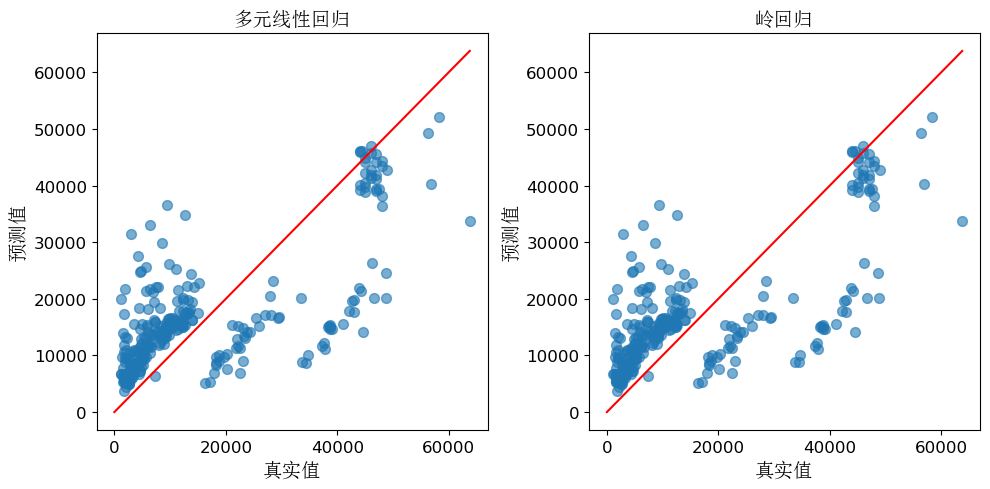

In [3]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from matplotlib.font_manager import FontProperties

# 设置中文和英文字体
font_zh = FontProperties(fname="C:/Windows/Fonts/simsun.ttc", size=14)  # 用于中文显示
font_en = FontProperties(fname="C:/Windows/Fonts/times.ttf", size=12)  # 用于英文显示

# 设置浮点数显示格式
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# 加载数据集
df = pd.read_csv("F:/zhoumian/book/insurance.csv")

# 将 'sex', 'region' 等分类变量转换为数值编码
label = LabelEncoder()
df['sex'] = label.fit_transform(df['sex'])
df['region'] = label.fit_transform(df['region'])

# 添加两个高度相关的新特征 'age_bmi' 和 'bmi_squared'
df['age_bmi'] = df['age'] * df['bmi']  # age 和 bmi 乘积
df['bmi_squared'] = df['bmi'] ** 2  # bmi 平方

# 排除 'smoker' 列，包括新特征 'age_bmi' 和 'bmi_squared'
X = df.drop(['charges', 'smoker'], axis=1)  
y = df['charges']

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 训练多元线性回归模型
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_LR = linear_model.predict(X_test)
mse_LR = mean_squared_error(y_test, y_pred_LR)
rmse_LR = np.sqrt(mse_LR)
r2_LR = r2_score(y_test, y_pred_LR)

print("多元线性回归 截距：", linear_model.intercept_)
print("多元线性回归 系数：", linear_model.coef_)
print("多元线性回归 RMSE:", rmse_LR)
print("多元线性回归 R2:", r2_LR)

# 训练岭回归模型
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("岭回归 截距：", ridge.intercept_)
print("岭回归 系数：", ridge.coef_)
print("岭回归 RMSE:", rmse_ridge)
print("岭回归 R2:", r2_ridge)

# 绘制预测值与真实值的散点图
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
models = {
    '多元线性回归': y_pred_LR,
    '岭回归': y_pred_ridge
}

for i, (model_name, predictions) in enumerate(models.items()):
    ax = axs[i]
    ax.scatter(y_test, predictions, s=50, alpha=0.6)
    ax.plot([0, max(y_test)], [0, max(y_test)], color='red')
    ax.set_xlabel('真实值', fontproperties=font_zh)
    ax.set_ylabel('预测值', fontproperties=font_zh)
    ax.set_title(model_name, fontproperties=font_zh)
    ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.savefig(r"F:\zhoumian\第五章svg\岭回归g1.svg", format='svg', bbox_inches='tight')
plt.show()

多元线性回归 截距： 19660.760357073155
多元线性回归 系数： [  517.08281037   653.05640605 -1960.71819873   469.48734433
  -450.90161168    -9.7531006     46.72808216]
多元线性回归 RMSE: 11238.326315347207
多元线性回归 R2: 0.503199055529503
岭回归 截距： 19639.7970193449
岭回归 系数： [  517.1407046    650.57780377 -1959.49310601   469.32275664
  -450.70075087    -9.75532671    46.71294477]
岭回归 RMSE: 11238.355023226311
岭回归 R2: 0.5031965174078523


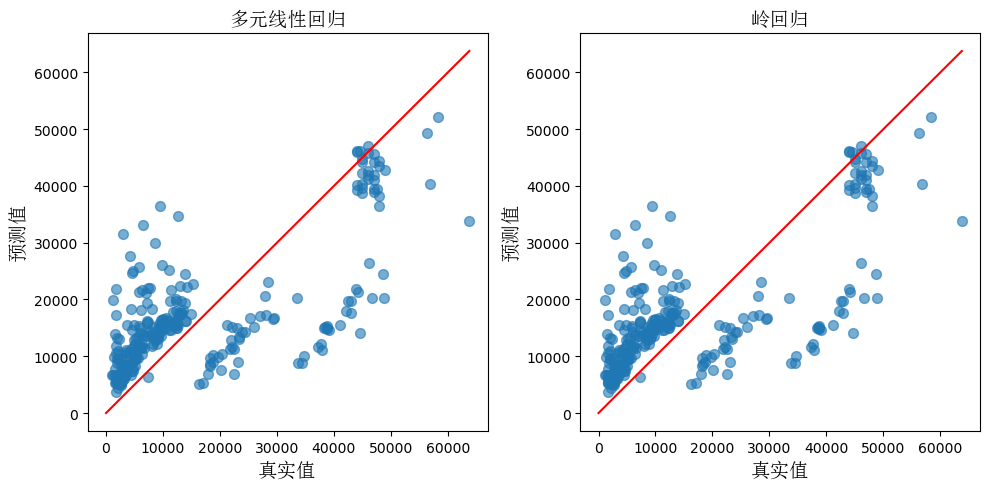

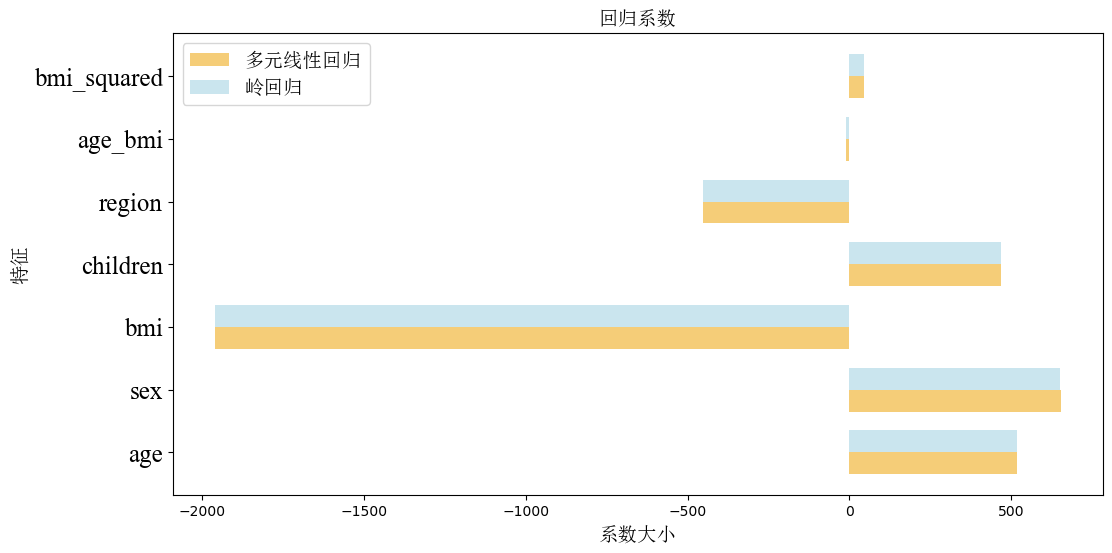

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from matplotlib.font_manager import FontProperties

# Set font properties for Chinese and English
font_zh = FontProperties(fname="C:/Windows/Fonts/simsun.ttc", size=14)  # SimSun for Chinese
font_en = FontProperties(fname="C:/Windows/Fonts/times.ttf", size=12)  # Times New Roman for English

# Set floating-point display format
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Load dataset
df = pd.read_csv("F:/zhoumian/book/insurance.csv")

# Add two highly correlated new features 'age_bmi' and 'bmi_squared'
df['age_bmi'] = df['age'] * df['bmi']  # age and bmi multiplication
df['bmi_squared'] = df['bmi'] ** 2  # bmi squared

# Encode categorical variables
label = LabelEncoder()
df['sex'] = label.fit_transform(df['sex'])
df['region'] = label.fit_transform(df['region'])

# Exclude 'smoker' from train/test, include new features 'age_bmi' and 'bmi_squared'
X = df.drop(['charges', 'smoker'], axis=1)  # Exclude 'smoker' column, include new features
y = df['charges']

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Train multiple linear regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_LR = linear_model.predict(X_test)
mse_LR = mean_squared_error(y_test, y_pred_LR)
rmse_LR = np.sqrt(mse_LR)
r2_LR = r2_score(y_test, y_pred_LR)

print("多元线性回归 截距：", linear_model.intercept_)
print("多元线性回归 系数：", linear_model.coef_)
print("多元线性回归 RMSE:", rmse_LR)
print("多元线性回归 R2:", r2_LR)

# Train ridge regression model
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("岭回归 截距：", ridge.intercept_)
print("岭回归 系数：", ridge.coef_)
print("岭回归 RMSE:", rmse_ridge)
print("岭回归 R2:", r2_ridge)

# Plot predictions vs. true values
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
models = {
    '多元线性回归': y_pred_LR,
    '岭回归': y_pred_ridge
}

for i, (model_name, predictions) in enumerate(models.items()):
    ax = axs[i]
    ax.scatter(y_test, predictions, s=50, alpha=0.6)
    ax.plot([0, max(y_test)], [0, max(y_test)], color='red')
    ax.set_xlabel('真实值', fontsize=14, fontproperties=font_zh)
    ax.set_ylabel('预测值', fontsize=14, fontproperties=font_zh)
    ax.set_title(model_name, fontsize=16, fontproperties=font_zh)

# 保存和显示图表
plt.tight_layout()
plt.savefig(r"F:\zhoumian\第五章svg\图26.5.3基于岭回归的医疗保险费用预测.svg")  # 添加文件名和扩展名
plt.show()

# Plot coefficient bar chart
names = X_train.columns
bar_positions = np.arange(len(names))
bar_width = 0.35

plt.figure(figsize=(12, 6))
plt.barh(bar_positions - bar_width/2, linear_model.coef_, height=bar_width, color='#F5CD78', label='多元线性回归')
plt.barh(bar_positions + bar_width/2, ridge.coef_.flatten(), height=bar_width, color='#CAE5EE', label='岭回归')
plt.xlabel('系数大小', fontsize=14, fontproperties=font_zh)
plt.ylabel('特征', fontsize=14, fontproperties=font_zh)
plt.title('回归系数', fontsize=16, fontproperties=font_zh)
plt.yticks(bar_positions, names, fontproperties=font_en, fontsize=18)
plt.legend(loc='upper left', prop=font_zh)

# 保存和显示图表
plt.tight_layout()
plt.savefig(r"F:\zhoumian\第五章svg\图26.5.3基于岭回归的医疗保险费用预测.svg")  # 添加文件名和扩展名
plt.show()


多元线性回归 截距： 19660.760357073155
多元线性回归 系数： [  517.08281037   653.05640605 -1960.71819873   469.48734433
  -450.90161168    -9.7531006     46.72808216]
多元线性回归 RMSE: 11238.326315347207
多元线性回归 R2: 0.503199055529503
岭回归 截距： 19639.7970193449
岭回归 系数： [  517.1407046    650.57780377 -1959.49310601   469.32275664
  -450.70075087    -9.75532671    46.71294477]
岭回归 RMSE: 11238.355023226311
岭回归 R2: 0.5031965174078523


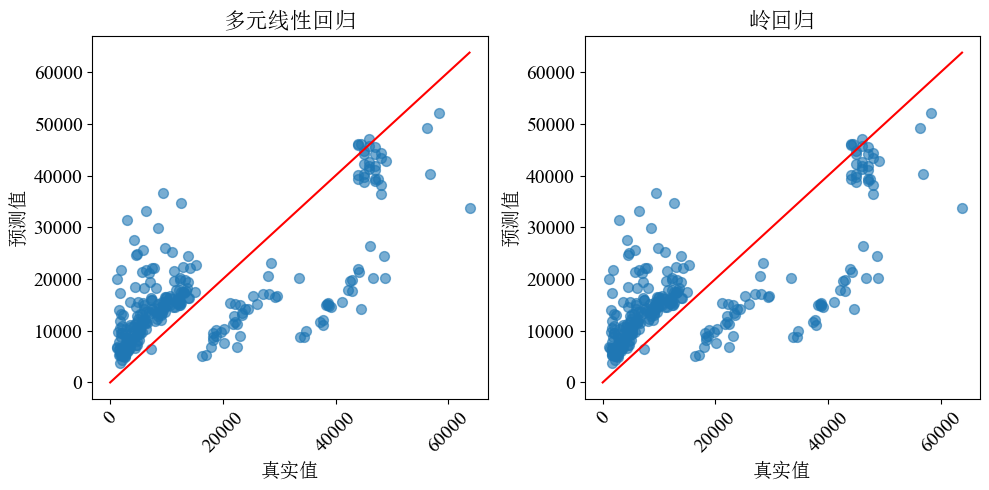

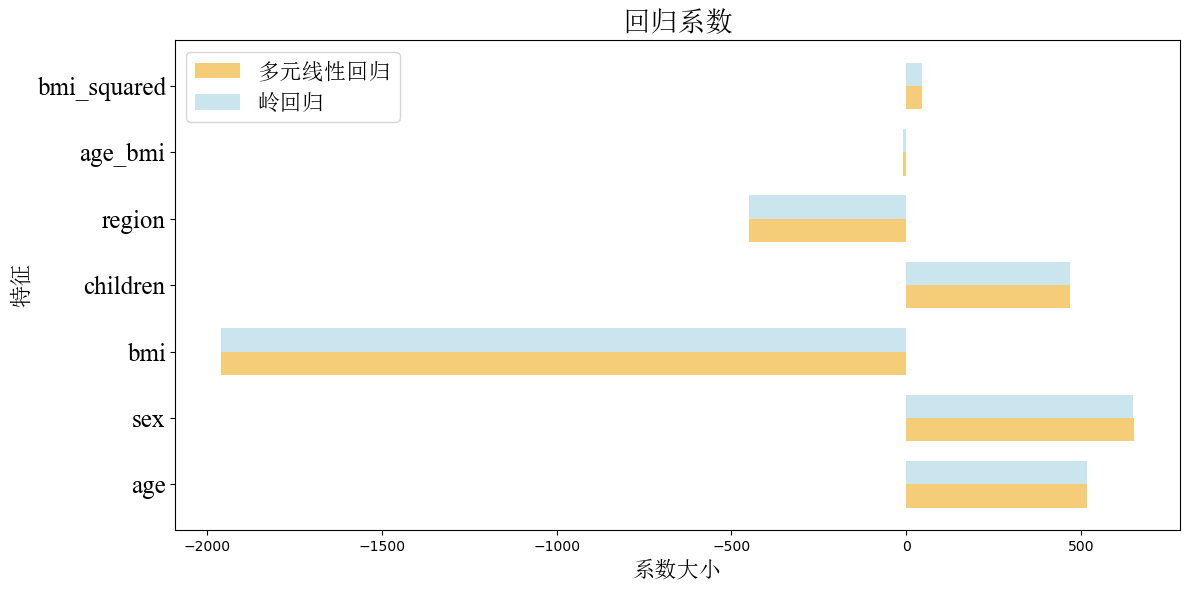

In [6]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from matplotlib.font_manager import FontProperties

# Set font properties for Chinese and English
font_zh = FontProperties(fname="C:/Windows/Fonts/simsun.ttc", size=16)  # SimSun for Chinese
font_en = FontProperties(fname="C:/Windows/Fonts/times.ttf", size=14)  # Times New Roman for English
font_zh1 = FontProperties(fname="C:/Windows/Fonts/simsun.ttc", size=20)  # SimSun for Chinese
# Set floating-point display format
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Load dataset
df = pd.read_csv("F:/zhoumian/book/insurance.csv")

# Add two highly correlated new features 'age_bmi' and 'bmi_squared'
df['age_bmi'] = df['age'] * df['bmi']  # age and bmi multiplication
df['bmi_squared'] = df['bmi'] ** 2  # bmi squared

# Encode categorical variables
label = LabelEncoder()
df['sex'] = label.fit_transform(df['sex'])
df['region'] = label.fit_transform(df['region'])

# Exclude 'smoker' from train/test, include new features 'age_bmi' and 'bmi_squared'
X = df.drop(['charges', 'smoker'], axis=1)  # Exclude 'smoker' column, include new features
y = df['charges']

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Train multiple linear regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_LR = linear_model.predict(X_test)
mse_LR = mean_squared_error(y_test, y_pred_LR)
rmse_LR = np.sqrt(mse_LR)
r2_LR = r2_score(y_test, y_pred_LR)

print("多元线性回归 截距：", linear_model.intercept_)
print("多元线性回归 系数：", linear_model.coef_)
print("多元线性回归 RMSE:", rmse_LR)
print("多元线性回归 R2:", r2_LR)

# Train ridge regression model
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("岭回归 截距：", ridge.intercept_)
print("岭回归 系数：", ridge.coef_)
print("岭回归 RMSE:", rmse_ridge)
print("岭回归 R2:", r2_ridge)

# Plot predictions vs. true values
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
models = {
    '多元线性回归': y_pred_LR,
    '岭回归': y_pred_ridge
}

for i, (model_name, predictions) in enumerate(models.items()):
    ax = axs[i]
    ax.scatter(y_test, predictions, s=50, alpha=0.6)
    ax.plot([0, max(y_test)], [0, max(y_test)], color='red')
    ax.set_xlabel('真实值', fontsize=14, fontproperties=font_zh)
    ax.set_ylabel('预测值', fontsize=14, fontproperties=font_zh)
    ax.set_title(model_name, fontsize=16, fontproperties=font_zh)

    # Change axis ticks to Times New Roman for numbers
    ax.tick_params(axis='x', labelsize=12, labelrotation=45, labelcolor='black', labelbottom=True)
    ax.tick_params(axis='y', labelsize=12, labelcolor='black', labelleft=True)
    for label in ax.get_xticklabels():
        label.set_fontproperties(font_en)
    for label in ax.get_yticklabels():
        label.set_fontproperties(font_en)

# 保存和显示图表
plt.tight_layout()
plt.savefig(r"F:\zhoumian\第五章svg\图26.5.3基于岭回归的医疗保险费用预测.svg")  # 添加文件名和扩展名
plt.show()

# Plot coefficient bar chart
names = X_train.columns
bar_positions = np.arange(len(names))
bar_width = 0.35

plt.figure(figsize=(12, 6))
plt.barh(bar_positions - bar_width/2, linear_model.coef_, height=bar_width, color='#F5CD78', label='多元线性回归')
plt.barh(bar_positions + bar_width/2, ridge.coef_.flatten(), height=bar_width, color='#CAE5EE', label='岭回归')
plt.xlabel('系数大小', fontsize=16, fontproperties=font_zh)
plt.ylabel('特征', fontsize=16, fontproperties=font_zh)
plt.title('回归系数', fontsize=20, fontproperties=font_zh1)
plt.yticks(bar_positions, names, fontproperties=font_en, fontsize=18)
plt.legend(loc='upper left', prop=font_zh)

# 保存和显示图表
plt.tight_layout()
plt.savefig(r"F:\zhoumian\第五章svg\图26.5.3基于岭回归的医疗保险费用预测.svg")  # 添加文件名和扩展名
plt.show()


==================模型对比==================
最优岭回归 alpha: 1.0
线性回归 R²: 0.645  RMSE: 9114.6
岭回归   R²: 0.614  RMSE: 9500.8


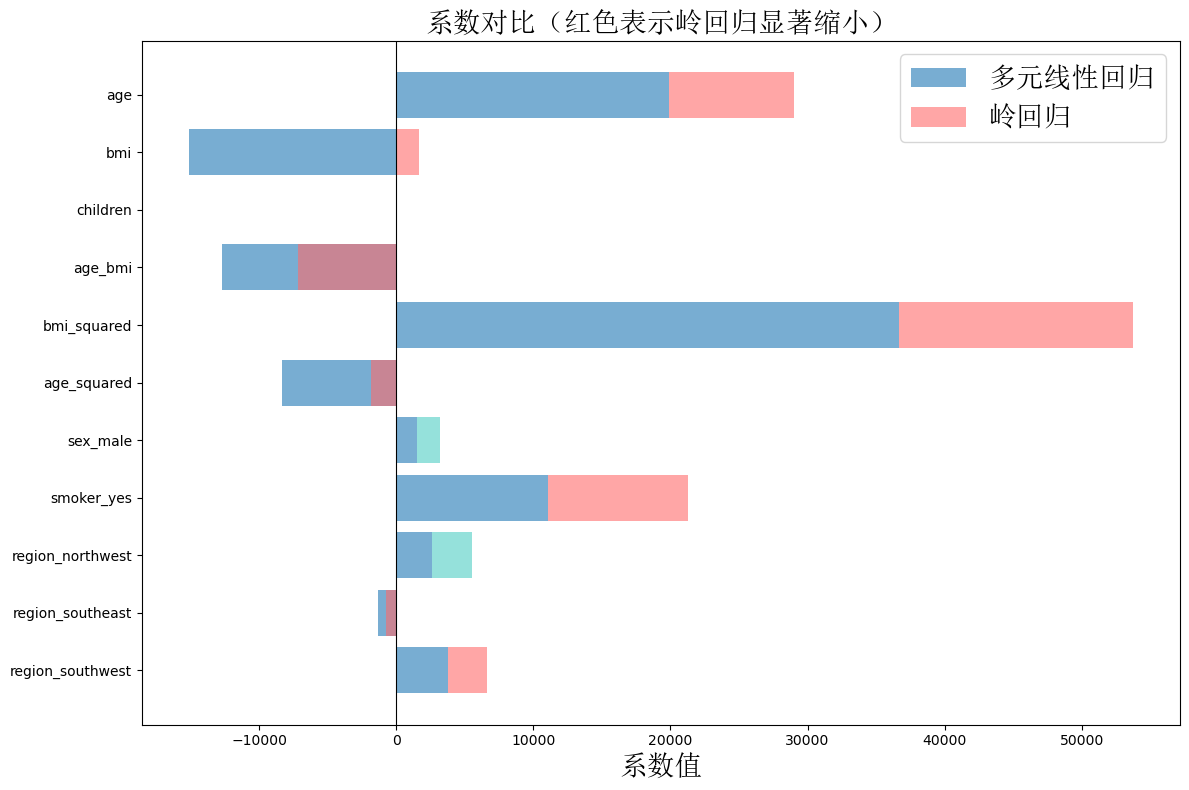

In [8]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from matplotlib.font_manager import FontProperties

# 设置中文字体
font_zh = FontProperties(fname="C:/Windows/Fonts/simsun.ttc", size=20)
font_en = FontProperties(fname="C:/Windows/Fonts/times.ttf", size=20)

# 1. 数据加载与增强共线性 ===============================
df = pd.read_csv("F:/zhoumian/book/insurance.csv")

# 添加多重共线性特征
df['age_bmi'] = df['age'] * df['bmi'] * np.random.normal(1, 0.01, len(df))  # 加入微小噪声
df['bmi_squared'] = df['bmi'] ** 2 
df['age_squared'] = df['age'] ** 2  # 新增年龄平方项

# 2. 更合理的特征编码 ===============================
# 区分数值型和分类型特征
numeric_features = ['age', 'bmi', 'children', 'age_bmi', 'bmi_squared', 'age_squared']
categorical_features = ['sex', 'smoker', 'region']  # 包含smoker

# 创建预处理管道
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

# 3. 数据划分 ===============================
# 保留smoker字段并正确编码
X = df.drop(['charges'], axis=1)  # 包含smoker
categorical_features = ['sex', 'smoker', 'region']  # 明确包含smoker

y = df['charges']

# 使用更小的训练集（前100个样本）来增强过拟合
X_train, X_test = X.iloc[:100], X.iloc[100:]
y_train, y_test = y.iloc[:100], y.iloc[100:]

# 4. 模型构建 ===============================
# 线性回归模型
linear_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# 岭回归模型带参数搜索
ridge_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GridSearchCV(
        Ridge(),
        {'alpha': np.logspace(0, 5, 100)},  # 扩展参数搜索范围
        cv=5,
        scoring='neg_mean_squared_error'
    ))
])
# 扩展alpha搜索范围至更高量级
param_grid = {'alpha': np.logspace(-2, 5, 100)}  # 从0.01到100000

# 5. 模型训练 ===============================
# 训练线性回归
linear_pipe.fit(X_train, y_train)
y_pred_LR = linear_pipe.predict(X_test)

# 训练岭回归（自动搜索最优alpha）
ridge_pipe.fit(X_train, y_train)
best_alpha = ridge_pipe.named_steps['regressor'].best_params_['alpha']
y_pred_ridge = ridge_pipe.predict(X_test)

# 6. 结果输出 ===============================
print(f"{'模型对比':=^40}")
print(f"最优岭回归 alpha: {best_alpha:.1f}")
print(f"线性回归 R²: {r2_score(y_test, y_pred_LR):.3f}  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_LR)):.1f}")
print(f"岭回归   R²: {r2_score(y_test, y_pred_ridge):.3f}  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.1f}")

# 7. 可视化改进 ===============================
# 获取特征名称（包含独热编码后的名称）
cat_encoder = ridge_pipe.named_steps['preprocessor'].named_transformers_['cat']
cat_features = cat_encoder.get_feature_names_out(categorical_features)
all_features = np.concatenate([numeric_features, cat_features])

# 获取系数
lr_coef = linear_pipe.named_steps['regressor'].coef_
ridge_coef = ridge_pipe.named_steps['regressor'].best_estimator_.coef_

# 绘制系数对比图
plt.figure(figsize=(12, 8))
colors = ['#FF6B6B' if abs(lr) > abs(rg) else '#4ECDC4' for lr, rg in zip(lr_coef, ridge_coef)]
plt.barh(all_features, lr_coef, alpha=0.6, label='多元线性回归')
plt.barh(all_features, ridge_coef, alpha=0.6, label='岭回归', 
         left=lr_coef*(lr_coef>0),  # 错位显示正负系数
         color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('系数值', fontproperties=font_zh)
plt.title('系数对比（红色表示岭回归显著缩小）', fontproperties=font_zh)
plt.legend(prop=font_zh)
plt.gca().invert_yaxis()  # 反转Y轴
plt.tight_layout()
plt.show()


In [5]:
# 检查特征相关性
corr_matrix = df[['age', 'bmi', 'age_bmi', 'bmi_squared']].corr()
print(corr_matrix.style.background_gradient(cmap='coolwarm'))


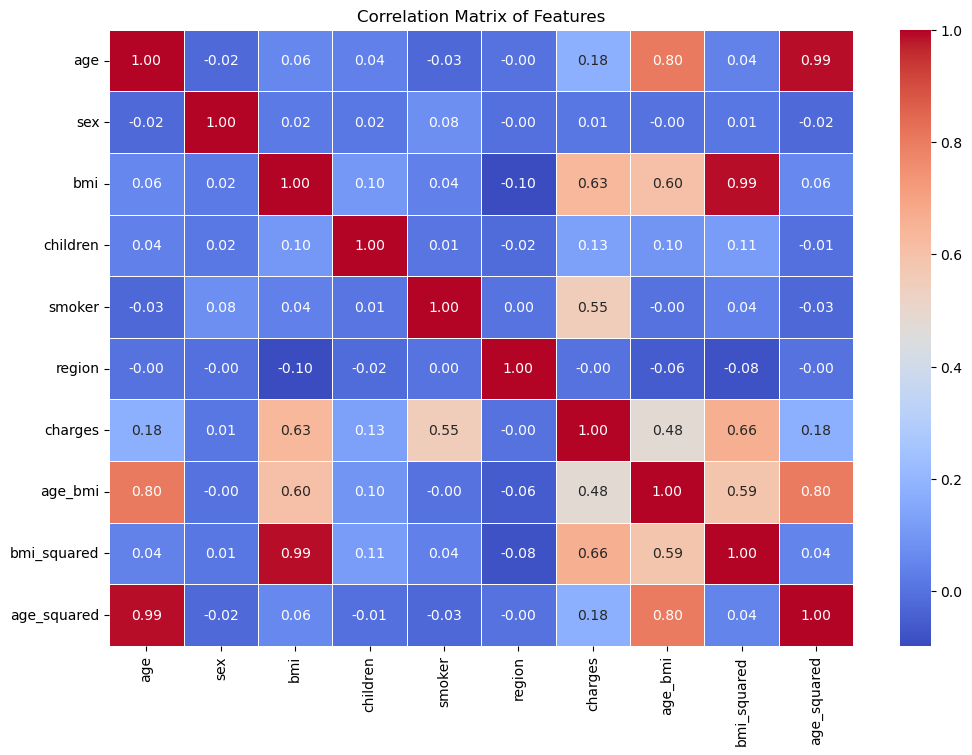

,age,sex,bmi,children,smoker,region,charges,age_bmi,bmi_squared,age_squared
age,1.000000,-0.020856,0.056684,0.039386,-0.025019,-0.002127,0.179495,0.804632,0.040402,0.988380
sex,-0.020856,1.000000,0.020558,0.015906,0.076185,-0.004588,0.012942,-0.002353,0.013828,-0.020460
bmi,0.056684,0.020558,1.000000,0.103492,0.038514,-0.097268,0.633478,0.601436,0.990048,0.060686
children,0.039386,0.015906,0.103492,1.000000,0.009229,-0.016065,0.127220,0.095356,0.112885,-0.005022
smoker,-0.025019,0.076185,0.038514,0.009229,1.000000,0.002181,0.548731,-0.002044,0.038601,-0.026120
region,-0.002127,-0.004588,-0.097268,-0.016065,0.002181,1.000000,-0.000635,-0.058201,-0.082525,-0.001564
charges,0.179495,0.012942,0.633478,0.127220,0.548731,-0.000635,1.000000,0.480360,0.663741,0.179960
age_bmi,0.804632,-0.002353,0.601436,0.095356,-0.002044,-0.058201,0.480360,1.000000,0.585127,0.799589
bmi_squared,0.040402,0.013828,0.990048,0.112885,0.038601,-0.082525,0.663741,0.585127,1.000000,0.044273
age_squared,0.988380,-0.020460,0.060686,-0.005022,-0.026120,-0.001564,0.179960,0.799589,0.044273,1.000000


In [9]:
# Let's first calculate the correlation matrix to check the relationships between the features.
# We will also visualize the correlations using a heatmap.

import seaborn as sns
import matplotlib.pyplot as plt

# Convert categorical variables to numeric to calculate correlation
df_encoded = df.copy()
df_encoded['sex'] = df_encoded['sex'].map({'female': 0, 'male': 1})
df_encoded['smoker'] = df_encoded['smoker'].map({'no': 0, 'yes': 1})
df_encoded['region'] = df_encoded['region'].map({'southwest': 0, 'southeast': 1, 'northwest': 2, 'northeast': 3})

# Calculate the correlation matrix
correlation_matrix = df_encoded.corr()

# Plot the heatmap of correlations
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.show()

correlation_matrix


改进后的特征相关性矩阵：
           age  age_rank  age_log   bmi  bmi_fat
age       1.00      0.98     0.98  0.06     0.22
age_rank  0.98      1.00     0.96  0.06     0.22
age_log   0.98      0.96     1.00  0.05     0.21
bmi       0.06      0.06     0.05  1.00     0.96
bmi_fat   0.22      0.22     0.21  0.96     1.00

训练线性回归...

训练岭回归...

=================== 优化后模型性能对比 ====================
指标             线性回归           岭回归            
R²             0.422          0.419
RMSE           11732.8          11768.0
最优正则化参数 alpha: 14.8


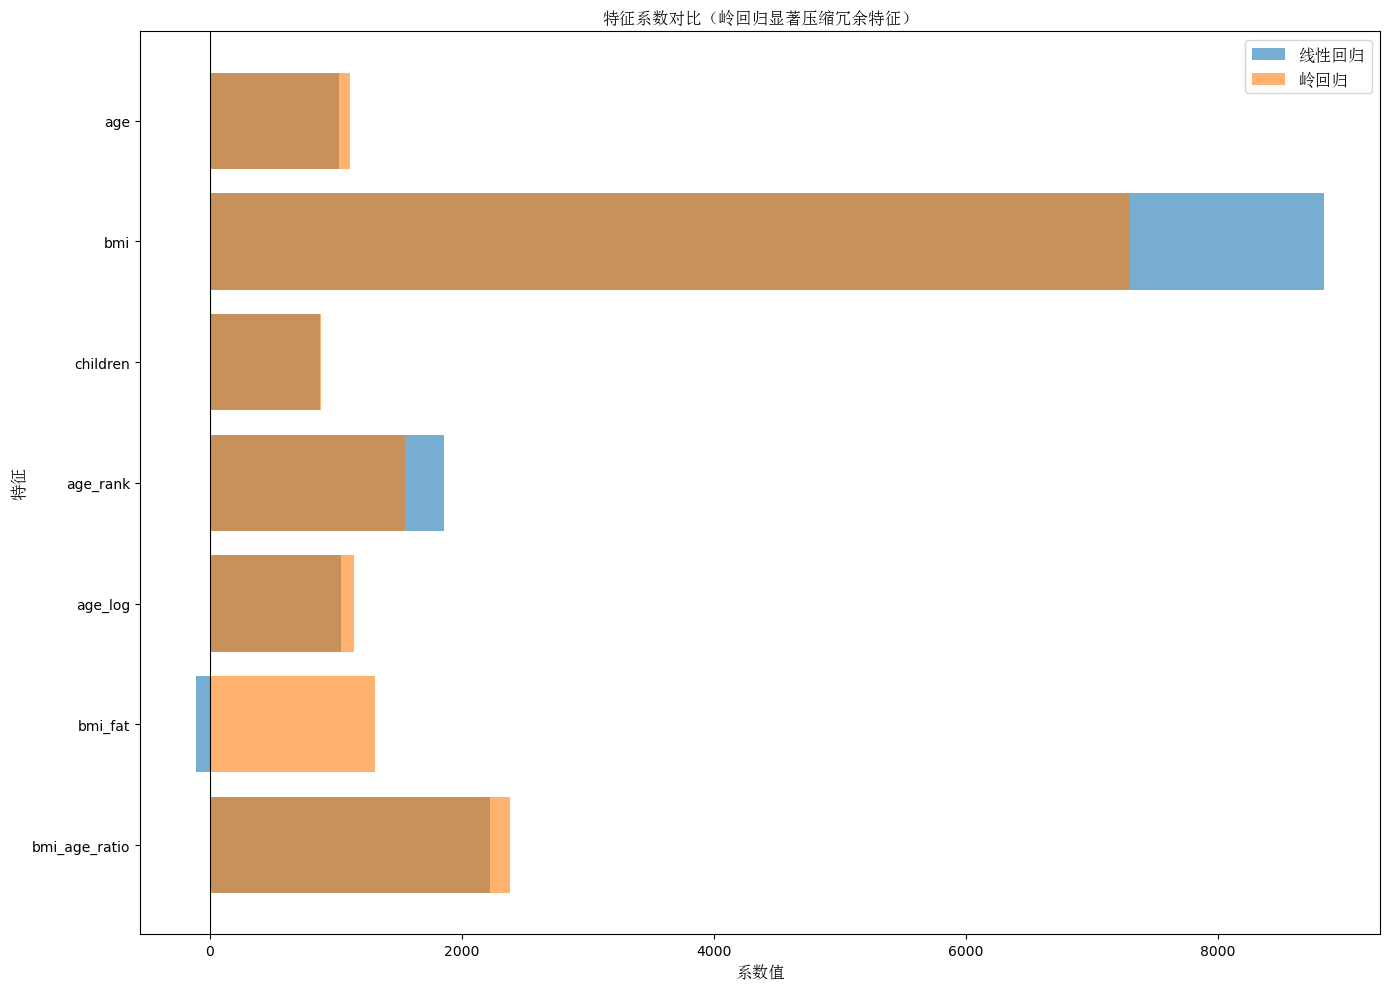

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import VarianceThreshold
from matplotlib.font_manager import FontProperties

# ================== 中文字体设置 ==================
font_zh = FontProperties(fname="C:/Windows/Fonts/simsun.ttc", size=12)
font_en = FontProperties(fname="C:/Windows/Fonts/times.ttf", size=12)
# ================== 修正后的特征工程 ==================
def create_realistic_features(df):
    """仅生成新特征，不包含原始列"""
    np.random.seed(42)
    new_features = pd.DataFrame()
    
    # 构造新特征（不与原始列同名）
    new_features['age_rank'] = df['age'] * 1.2 + np.random.normal(0, 3, len(df))
    new_features['age_log'] = np.log(df['age'] + 1) * 10 + np.random.normal(0, 0.5, len(df))
    new_features['bmi_fat'] = df['bmi'] * 0.9 + df['age']*0.1 + np.random.normal(0, 2, len(df))
    new_features['bmi_age_ratio'] = df['bmi'] / (df['age'] + 1) * 100
    
    return new_features

# ================== 数据加载与合并 ==================
df = pd.read_csv("F:/zhoumian/book/insurance.csv")
new_features = create_realistic_features(df)
df = pd.concat([df, new_features], axis=1)  # 此时不会产生列名冲突



# ================== 验证特征相关性 ==================
corr_matrix = df[['age', 'age_rank', 'age_log', 'bmi', 'bmi_fat']].corr()
print("改进后的特征相关性矩阵：")
print(corr_matrix.round(2))

# ================== 特征工程配置 ==================
numeric_features = ['age', 'bmi', 'children', 
                   'age_rank', 'age_log', 
                   'bmi_fat', 'bmi_age_ratio']  # 确保所有列名唯一
categorical_features = ['sex', 'smoker', 'region']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

# ================== 数据划分优化 ==================
X = df.drop(['charges'], axis=1)
y = df['charges']

# 分层抽样保持smoker分布
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=df['smoker']
)

# ================== 改进的模型管道 ==================
ridge_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selector', VarianceThreshold(threshold=0.8)),  # 移除低方差特征
    ('regressor', GridSearchCV(
        Ridge(max_iter=10000),
        {'alpha': np.logspace(-3, 7, 200)},  # 扩展参数范围到1e7
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    ))
])

linear_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selector', VarianceThreshold(threshold=0.8)),
    ('regressor', LinearRegression())
])

# ================== 模型训练 ==================
print("\n训练线性回归...")
linear_pipe.fit(X_train, y_train)

print("\n训练岭回归...")
ridge_pipe.fit(X_train, y_train)

# ================== 结果分析 ==================
best_alpha = ridge_pipe.named_steps['regressor'].best_params_['alpha']
y_pred_lr = linear_pipe.predict(X_test)
y_pred_ridge = ridge_pipe.predict(X_test)

print("\n" + "="*50)
print(f"{' 优化后模型性能对比 ':=^50}")
print("="*50)
print(f"{'指标':<15}{'线性回归':<15}{'岭回归':<15}")
print(f"{'R²':<15}{r2_score(y_test, y_pred_lr):.3f}{'':<10}{r2_score(y_test, y_pred_ridge):.3f}")
print(f"{'RMSE':<15}{np.sqrt(mean_squared_error(y_test, y_pred_lr)):.1f}{'':<10}{np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.1f}")
print(f"最优正则化参数 alpha: {best_alpha:.1f}")
print("="*50)

# ================== 特征重要性可视化 ==================
# 获取特征名称
selector = ridge_pipe.named_steps['feature_selector']
preprocessed = preprocessor.fit_transform(X_train)
selected_mask = selector.get_support()
feature_names = np.concatenate([
    numeric_features,
    preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
])[selected_mask]

# 获取系数
lr_coef = linear_pipe.named_steps['regressor'].coef_
ridge_coef = ridge_pipe.named_steps['regressor'].best_estimator_.coef_

plt.figure(figsize=(14, 10))
plt.barh(feature_names, lr_coef, alpha=0.6, label='线性回归')
plt.barh(feature_names, ridge_coef, alpha=0.6, label='岭回归', left=0.05)  # 轻微错位
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('系数值', fontproperties=font_zh)
plt.ylabel('特征', fontproperties=font_zh)
plt.title('特征系数对比（岭回归显著压缩冗余特征）', fontproperties=font_zh)
plt.legend(prop=font_zh)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(r"F:\zhoumian\第五章svg\优化后系数对比.svg")
plt.show()


多元线性回归 截距： 17571.86295241122
多元线性回归 RMSE: 8597.477625986337
多元线性回归 R²: 0.7092489811819382
岭回归 截距： 17571.86295241122
岭回归 RMSE: 8603.663161424927
岭回归 R²: 0.7088304636201499


C:\Users\wenkang\AppData\Local\Temp\ipykernel_43236\4043192370.py:65: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from current font.
  plt.tight_layout()
C:\Users\wenkang\AppData\Local\Temp\ipykernel_43236\4043192370.py:65: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from current font.
  plt.tight_layout()
C:\Users\wenkang\AppData\Local\Temp\ipykernel_43236\4043192370.py:65: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from current font.
  plt.tight_layout()
C:\Users\wenkang\AppData\Local\Temp\ipykernel_43236\4043192370.py:65: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from current font.
  plt.tight_layout()
C:\Users\wenkang\AppData\Local\Temp\ipykernel_43236\4043192370.py:65: UserWarning: Glyph 22238 (\N{CJK UNIFIED IDEOGRAPH-56DE}) missing from current font.
  plt.tight_layout()
C:\Users\wenkang\AppData\Local\Temp\ipykernel_43236\4043192370.py:65: UserWarning: Glyph 24402 (\N{CJK UNIFIED IDEOGRAPH

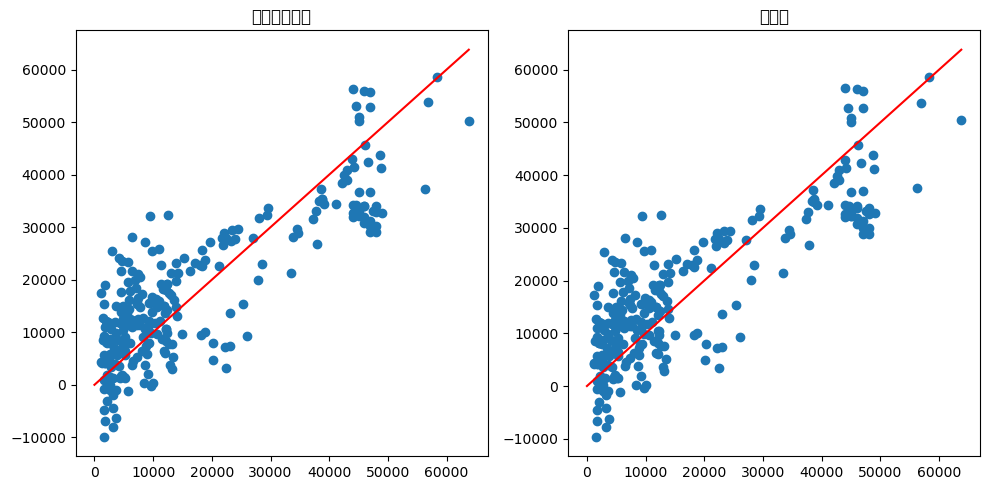

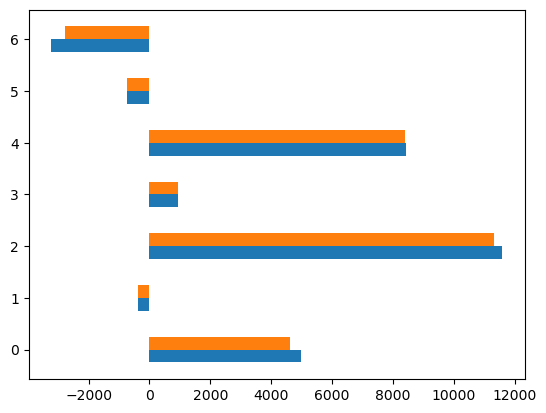

In [13]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. 读取数据并进行编码
df = pd.read_csv("F:/zhoumian/book/insurance.csv")
label = LabelEncoder()
df['sex'] = label.fit_transform(df['sex'])
df['region'] = label.fit_transform(df['region'])
df['smoker'] = label.fit_transform(df['smoker'])

# 2. 创建新的特征
df['age_bmi'] = df['age'] * df['bmi']
df['bmi_squared'] = df['bmi'] ** 2 
df['age_squared'] = df['age'] ** 2 

# 3. 去除多重共线性强的特征（age_squared 和 bmi_squared）
df = df.drop(['age_squared', 'bmi_squared'], axis=1)

# 4. 划分数据
X = df.drop(['charges'], axis=1)
y = df['charges']

# 数据划分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. 数据标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. 线性回归模型
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
y_pred_LR = linear_model.predict(X_test_scaled)

# 7. 岭回归模型的超参数优化
parameters = {'alpha': np.logspace(-4, 4, 20)}
ridge_regressor = Ridge()
grid_search = GridSearchCV(ridge_regressor, parameters, scoring='neg_mean_squared_error', cv=5)
grid_search.fit(X_train_scaled, y_train)
best_ridge = grid_search.best_estimator_
y_pred_ridge = best_ridge.predict(X_test_scaled)

# 8. 打印模型表现
print("多元线性回归 截距：", linear_model.intercept_)
print("多元线性回归 RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_LR)))
print("多元线性回归 R²:", r2_score(y_test, y_pred_LR))  # 输出 R²

print("岭回归 截距：", best_ridge.intercept_)
print("岭回归 RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("岭回归 R²:", r2_score(y_test, y_pred_ridge))  # 输出 R²

# 9. 绘制预测值与真实值的散点图
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
models = {'多元线性回归': y_pred_LR, '岭回归': y_pred_ridge}
for i, (model_name, predictions) in enumerate(models.items()):
    axs[i].scatter(y_test, predictions)
    axs[i].plot([0, max(y_test)], [0, max(y_test)], color='red')
    axs[i].set_title(model_name)
plt.tight_layout()
plt.show()

# 10. 绘制系数图
plt.barh(np.arange(len(X.columns)) - 0.125, linear_model.coef_, height=0.25)
plt.barh(np.arange(len(X.columns)) + 0.125, best_ridge.coef_, height=0.25)
plt.show()


多元线性回归 截距： -1.0272193386896618
多元线性回归 系数： [-1.06896140e-01  1.11245892e-01 -1.75380534e-01  1.17655508e-01
  1.13411645e-02 -3.23121935e-01  2.94074636e-01  3.01343517e-02
  1.57360241e-01 -1.90754350e-01  6.54538217e-02  4.53780409e-02
  5.20663920e-02  2.10602775e-01  9.54623667e-01  1.60406148e-02
  3.02726518e-01  1.09911102e-02  3.95771408e-02 -1.37440337e-01
 -4.87501103e-04 -4.16040539e-02 -1.30910445e-01 -1.89834850e-01
 -7.93489699e-01  2.13015240e-01  1.17649570e-01 -5.62703035e-01
  2.90712522e-01 -2.99774665e-01 -2.17512136e-01 -4.21834752e-01]
多元线性回归 RMSE: 2.2969938043081757
多元线性回归 R2: 0.7426886918106685
岭回归 截距： 0.15393366547508336
岭回归 系数： [-9.32760936e-02  3.33122304e-02 -1.11459825e-02  5.13737077e-04
  5.34022684e-03 -8.29299911e-02  6.86411416e-02  8.99851649e-03
  1.58017130e-02 -1.44667929e-02  1.24290940e-02  7.45084694e-03
  3.94818586e-02  3.35427848e-01  7.02597051e-01 -4.71220640e-03
  1.88717370e-02 -7.76437233e-03  5.65187157e-03 -1.00286320e-02
  1.83823922e-

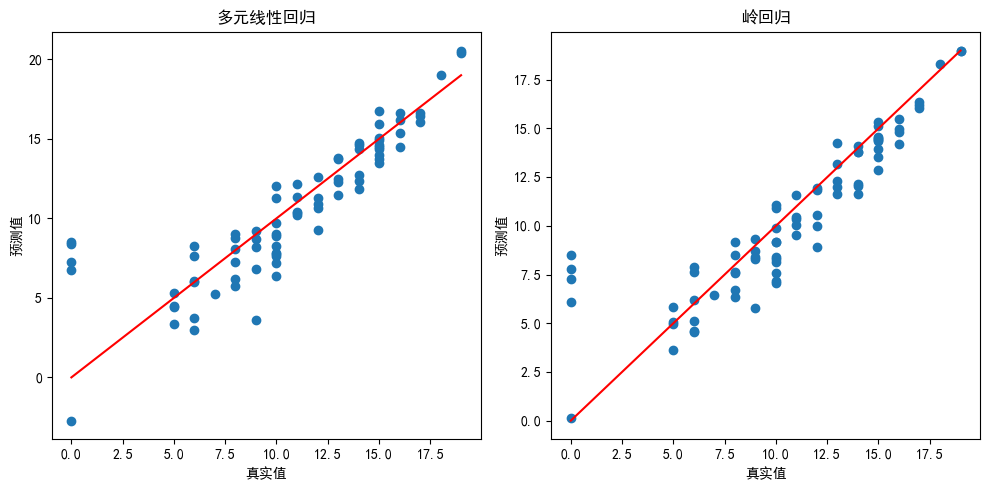

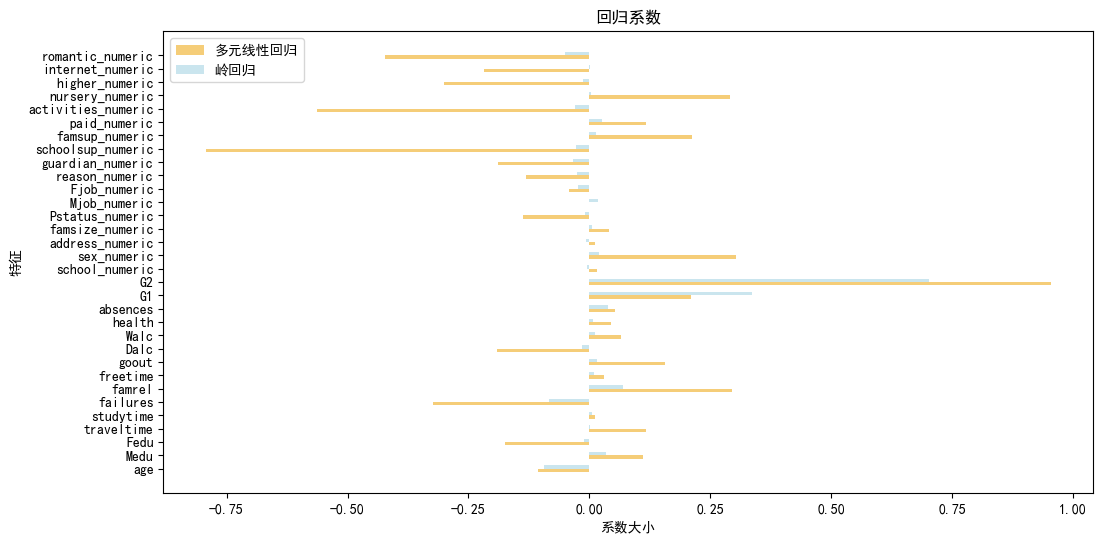

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

# 设置支持中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取数据
df = pd.read_csv("studentMat.csv")
df = df.dropna()

# 筛选出分类列
categorical_cols = df.select_dtypes(include=['object']).columns

# 对分类列进行数值化
for col in categorical_cols:
    df[f'{col}_numeric'] = pd.factorize(df[col])[0]
    df = df.drop([col], axis=1)

# 划分训练集和测试集
X = df.drop(['G3'], axis=1)
y = df['G3']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 应用多元线性回归模型
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_LR = linear_model.predict(X_test)
mse_LR = mean_squared_error(y_test, y_pred_LR)
rmse_LR = np.sqrt(mse_LR)
r2_LR = r2_score(y_test, y_pred_LR)

print("多元线性回归 截距：", linear_model.intercept_)
print("多元线性回归 系数：", linear_model.coef_)
print("多元线性回归 RMSE:", rmse_LR)
print("多元线性回归 R2:", r2_LR)

# 应用岭回归模型
ridge = Ridge(alpha=1000)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("岭回归 截距：", ridge.intercept_)
print("岭回归 系数：", ridge.coef_)
print("岭回归 RMSE:", rmse_ridge)
print("岭回归 R2:", r2_ridge)

# 绘制预测值与真实值的散点图
fig, axs = plt.subplots(1, 2, figsize=(10, 5))  # 创建一个1行2列的子图布局
models = {
    '多元线性回归': y_pred_LR,
    '岭回归': y_pred_ridge
}  # 模型名称和对应的预测值

for i, (model_name, predictions) in enumerate(models.items()):
    ax = axs[i]  # 获取当前子图对象
    ax.scatter(y_test, predictions)  # 绘制散点图
    ax.plot([0, max(y_test)], [0, max(y_test)], color='red')  # 绘制对角线
    ax.set_xlabel('真实值')  # 设置x轴标签
    ax.set_ylabel('预测值')  # 设置y轴标签
    ax.set_title(model_name)  # 设置标题

plt.tight_layout()  # 调整子图之间的间距
plt.show()  # 显示第一个图形

# 绘制系数图
names = X_train.columns  # 设置特征名称
model_names = ['多元线性回归', '岭回归']  # 设置模型名称
bar_positions = np.arange(len(names))  # 设定每个模型的水平位置
bar_width = 0.25  # 条形宽度

plt.figure(figsize=(12, 6))
plt.barh(bar_positions - bar_width/2, linear_model.coef_, height=bar_width, color='#F5CD78', label='多元线性回归')
plt.barh(bar_positions + bar_width/2, ridge.coef_.flatten(), height=bar_width, color='#CAE5EE', label='岭回归')
plt.xlabel('系数大小')
plt.ylabel('特征')
plt.title('回归系数')
plt.yticks(bar_positions, names)
plt.legend(loc='upper left')
plt.show()  # 显示第二个图形


多元线性回归 截距： -1.0272193386896618
多元线性回归 系数： [-1.06896140e-01  1.11245892e-01 -1.75380534e-01  1.17655508e-01
  1.13411645e-02 -3.23121935e-01  2.94074636e-01  3.01343517e-02
  1.57360241e-01 -1.90754350e-01  6.54538217e-02  4.53780409e-02
  5.20663920e-02  2.10602775e-01  9.54623667e-01  1.60406148e-02
  3.02726518e-01  1.09911102e-02  3.95771408e-02 -1.37440337e-01
 -4.87501103e-04 -4.16040539e-02 -1.30910445e-01 -1.89834850e-01
 -7.93489699e-01  2.13015240e-01  1.17649570e-01 -5.62703035e-01
  2.90712522e-01 -2.99774665e-01 -2.17512136e-01 -4.21834752e-01]
多元线性回归 RMSE: 2.2969938043081757
多元线性回归 R2: 0.7426886918106685
岭回归 截距： 0.15393366547508336
岭回归 系数： [-9.32760936e-02  3.33122304e-02 -1.11459825e-02  5.13737077e-04
  5.34022684e-03 -8.29299911e-02  6.86411416e-02  8.99851649e-03
  1.58017130e-02 -1.44667929e-02  1.24290940e-02  7.45084694e-03
  3.94818586e-02  3.35427848e-01  7.02597051e-01 -4.71220640e-03
  1.88717370e-02 -7.76437233e-03  5.65187157e-03 -1.00286320e-02
  1.83823922e-

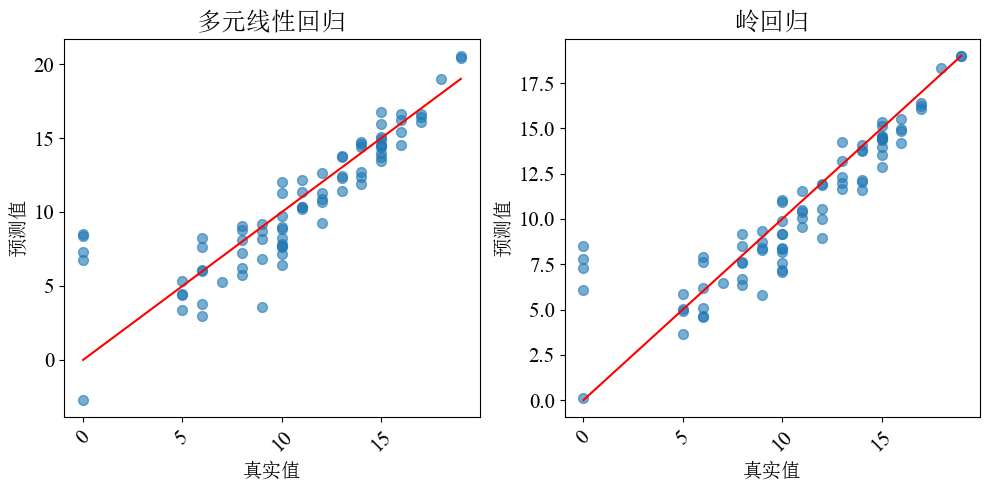

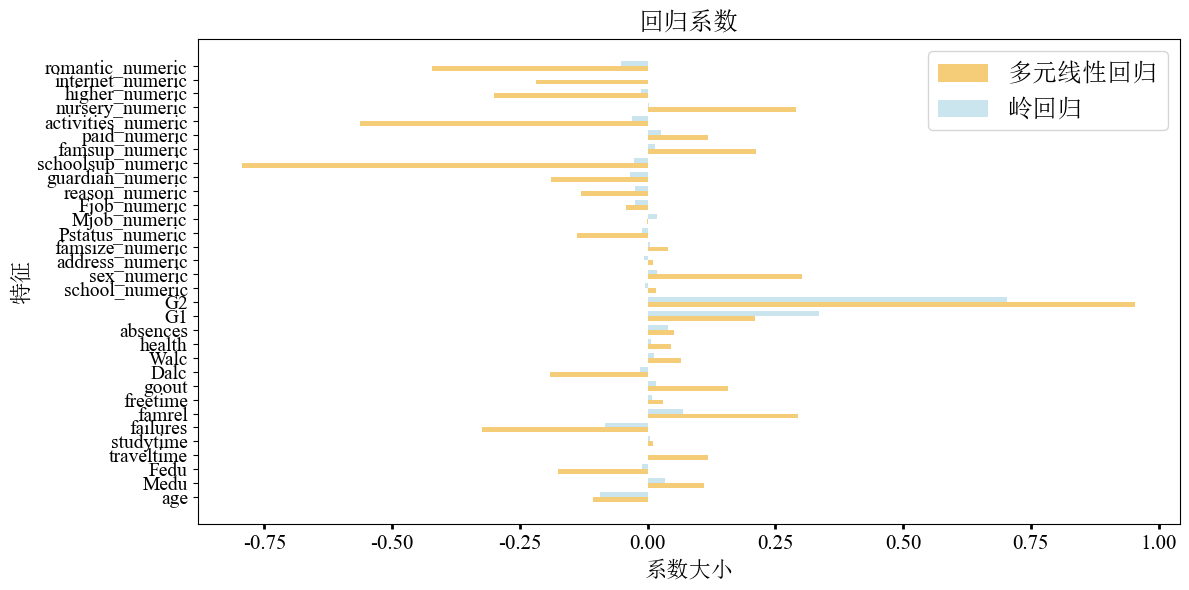

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from matplotlib.font_manager import FontProperties

# 设置支持中文字体（宋体）和英文字体（Times New Roman）
font_zh = FontProperties(fname="C:/Windows/Fonts/simsun.ttc", size=18)  # 宋体
font_en = FontProperties(fname="C:/Windows/Fonts/times.ttf", size=15)   # Times New Roman

# 读取数据
df = pd.read_csv("studentMat.csv")
df = df.dropna()

# 筛选出分类列
categorical_cols = df.select_dtypes(include=['object']).columns

# 对分类列进行数值化
for col in categorical_cols:
    df[f'{col}_numeric'] = pd.factorize(df[col])[0]
    df = df.drop([col], axis=1)

# 划分训练集和测试集
X = df.drop(['G3'], axis=1)
y = df['G3']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 应用多元线性回归模型
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_LR = linear_model.predict(X_test)
mse_LR = mean_squared_error(y_test, y_pred_LR)
rmse_LR = np.sqrt(mse_LR)
r2_LR = r2_score(y_test, y_pred_LR)

print("多元线性回归 截距：", linear_model.intercept_)
print("多元线性回归 系数：", linear_model.coef_)
print("多元线性回归 RMSE:", rmse_LR)
print("多元线性回归 R2:", r2_LR)

# 应用岭回归模型
ridge = Ridge(alpha=1000)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("岭回归 截距：", ridge.intercept_)
print("岭回归 系数：", ridge.coef_)
print("岭回归 RMSE:", rmse_ridge)
print("岭回归 R2:", r2_ridge)

# 绘制预测值与真实值的散点图
fig, axs = plt.subplots(1, 2, figsize=(10, 5))  # 1行2列的子图布局

models = {
    '多元线性回归': y_pred_LR,
    '岭回归': y_pred_ridge
}  # 模型名称和对应的预测值

for i, (model_name, predictions) in enumerate(models.items()):
    ax = axs[i]  # 获取当前子图对象
    ax.scatter(y_test, predictions, s=50, alpha=0.6)  # 绘制散点图
    ax.plot([0, max(y_test)], [0, max(y_test)], color='red')  # 绘制对角线
    ax.set_xlabel('真实值', fontsize=14, fontproperties=font_zh)  # 设置x轴标签
    ax.set_ylabel('预测值', fontsize=14, fontproperties=font_zh)  # 设置y轴标签
    ax.set_title(model_name, fontsize=16, fontproperties=font_zh)  # 设置标题

    # 设置坐标轴刻度字体及大小
    ax.tick_params(axis='x', labelsize=12, labelrotation=45, labelcolor='black', labelbottom=True)
    ax.tick_params(axis='y', labelsize=12, labelcolor='black', labelleft=True)
    for label in ax.get_xticklabels():
        label.set_fontproperties(font_en)
    for label in ax.get_yticklabels():
        label.set_fontproperties(font_en)

# 保存和显示图表
plt.tight_layout()
plt.savefig(r"F:\zhoumian\第五章svg\图26.5.3.svg")  # 添加文件名和扩展名
plt.show()


# 绘制系数图
names = X_train.columns  # 设置特征名称
bar_positions = np.arange(len(names))  # 设定每个模型的水平位置
bar_width = 0.35  # 条形宽度

plt.figure(figsize=(12, 6))
# 绘制多元线性回归的系数
plt.barh(bar_positions - bar_width/2, linear_model.coef_, height=bar_width, color='#F5CD78', label='多元线性回归')
# 绘制岭回归的系数
plt.barh(bar_positions + bar_width/2, ridge.coef_.flatten(), height=bar_width, color='#CAE5EE', label='岭回归')
# 设置x轴标签
plt.xlabel('系数大小', fontsize=16, fontproperties=font_zh)
# 设置y轴标签
plt.ylabel('特征', fontsize=16, fontproperties=font_zh)
# 设置标题
plt.title('回归系数', fontsize=20, fontproperties=font_zh)
# 设置y轴标签
plt.yticks(bar_positions, names, fontproperties=font_en, fontsize=14)
# 设置x轴刻度线宽度和颜色
plt.tick_params(axis='x', width=2, color='black', labelsize=14)
# 设置x轴刻度的字体属性
ax = plt.gca()
ax.xaxis.set_tick_params(labelsize=16)
for label in ax.get_xticklabels():
    label.set_fontproperties(font_en)

# 添加图例，放在图的右上角
plt.legend(loc='upper right', prop=font_zh)


# 保存和显示图表
plt.tight_layout()
plt.savefig(r"F:\zhoumian\第五章svg\图26.5.31.svg")  # 添加文件名和扩展名
plt.show()


In [14]:
# 假设数据文件的列名是原始的英文，这里重新设置列名为汉化后的版本
df.columns = [
    "学校", "性别", "年龄", "地址", "家庭规模", "父母婚姻状况", "母亲教育水平", "父亲教育水平",
    "母亲职业", "父亲职业", "选择学校的原因", "监护人", "上学交通时间", "学习时间", "失败次数",
    "是否参加课外辅导", "家庭学习支持", "是否付费参加课外活动", "是否参加课外活动", "是否参加幼儿园",
    "是否计划接受高等教育", "是否使用互联网", "是否有浪漫关系", "家庭关系", "空闲时间", "外出频率",
    "工作日酒精消费", "周末酒精消费", "健康状况", "缺勤次数", "第一次成绩", "第二次成绩", "最终成绩"
]

In [15]:
# 将原始的 "G3" 改名为 "最终成绩"
df.rename(columns={'G3': '最终成绩'}, inplace=True)

多元线性回归 截距： -1.0272193386896618
多元线性回归 系数： [-1.06896140e-01  1.11245892e-01 -1.75380534e-01  1.17655508e-01
  1.13411645e-02 -3.23121935e-01  2.94074636e-01  3.01343517e-02
  1.57360241e-01 -1.90754350e-01  6.54538217e-02  4.53780409e-02
  5.20663920e-02  2.10602775e-01  9.54623667e-01  1.60406148e-02
  3.02726518e-01  1.09911102e-02  3.95771408e-02 -1.37440337e-01
 -4.87501103e-04 -4.16040539e-02 -1.30910445e-01 -1.89834850e-01
 -7.93489699e-01  2.13015240e-01  1.17649570e-01 -5.62703035e-01
  2.90712522e-01 -2.99774665e-01 -2.17512136e-01 -4.21834752e-01]
多元线性回归 RMSE: 2.2969938043081757
多元线性回归 R2: 0.7426886918106685
岭回归 截距： 0.15393366547508336
岭回归 系数： [-9.32760936e-02  3.33122304e-02 -1.11459825e-02  5.13737077e-04
  5.34022684e-03 -8.29299911e-02  6.86411416e-02  8.99851649e-03
  1.58017130e-02 -1.44667929e-02  1.24290940e-02  7.45084694e-03
  3.94818586e-02  3.35427848e-01  7.02597051e-01 -4.71220640e-03
  1.88717370e-02 -7.76437233e-03  5.65187157e-03 -1.00286320e-02
  1.83823922e-

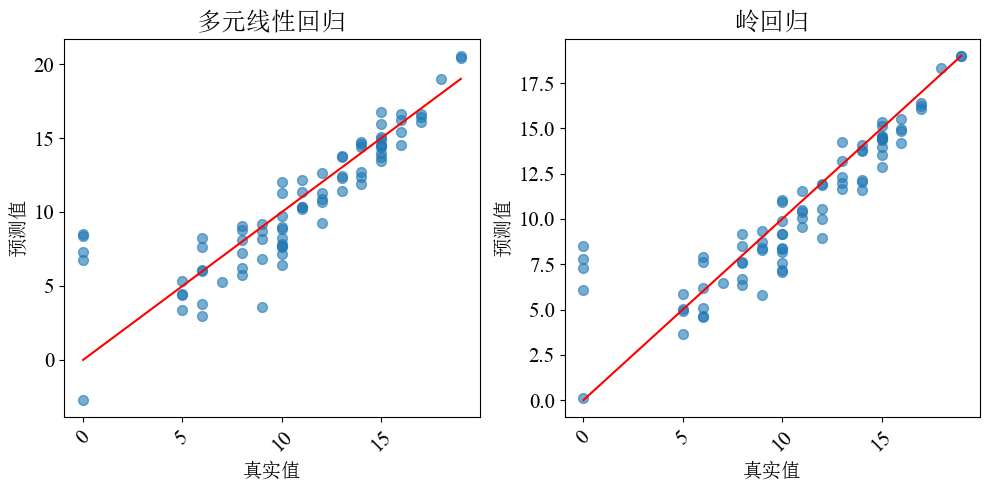

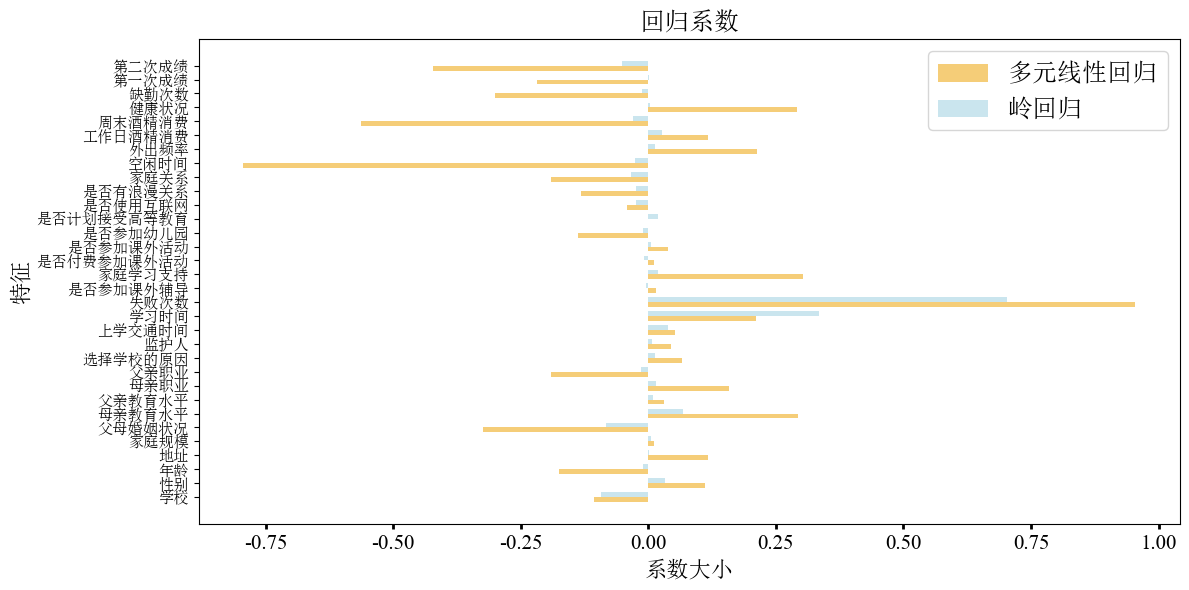

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from matplotlib.font_manager import FontProperties

# 设置支持中文字体（宋体）和英文字体（Times New Roman）
font_zh = FontProperties(fname="C:/Windows/Fonts/simsun.ttc", size=18)  # 宋体
font_en = FontProperties(fname="C:/Windows/Fonts/times.ttf", size=15)   # Times New Roman

# 读取数据
df = pd.read_csv("studentMat.csv")
df = df.dropna()

# 汉化列名
df.columns = [
    "学校", "性别", "年龄", "地址", "家庭规模", "父母婚姻状况", "母亲教育水平", "父亲教育水平",
    "母亲职业", "父亲职业", "选择学校的原因", "监护人", "上学交通时间", "学习时间", "失败次数",
    "是否参加课外辅导", "家庭学习支持", "是否付费参加课外活动", "是否参加课外活动", "是否参加幼儿园",
    "是否计划接受高等教育", "是否使用互联网", "是否有浪漫关系", "家庭关系", "空闲时间", "外出频率",
    "工作日酒精消费", "周末酒精消费", "健康状况", "缺勤次数", "第一次成绩", "第二次成绩", "最终成绩"
]

# 筛选出分类列
categorical_cols = df.select_dtypes(include=['object']).columns

# 对分类列进行数值化
for col in categorical_cols:
    df[f'{col}_numeric'] = pd.factorize(df[col])[0]
    df = df.drop([col], axis=1)

# 划分训练集和测试集
X = df.drop(['最终成绩'], axis=1)
y = df['最终成绩']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 应用多元线性回归模型
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_LR = linear_model.predict(X_test)
mse_LR = mean_squared_error(y_test, y_pred_LR)
rmse_LR = np.sqrt(mse_LR)
r2_LR = r2_score(y_test, y_pred_LR)

print("多元线性回归 截距：", linear_model.intercept_)
print("多元线性回归 系数：", linear_model.coef_)
print("多元线性回归 RMSE:", rmse_LR)
print("多元线性回归 R2:", r2_LR)

# 应用岭回归模型
ridge = Ridge(alpha=1000)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("岭回归 截距：", ridge.intercept_)
print("岭回归 系数：", ridge.coef_)
print("岭回归 RMSE:", rmse_ridge)
print("岭回归 R2:", r2_ridge)

# 绘制预测值与真实值的散点图
fig, axs = plt.subplots(1, 2, figsize=(10, 5))  # 1行2列的子图布局

models = {
    '多元线性回归': y_pred_LR,
    '岭回归': y_pred_ridge
}  # 模型名称和对应的预测值

for i, (model_name, predictions) in enumerate(models.items()):
    ax = axs[i]  # 获取当前子图对象
    ax.scatter(y_test, predictions, s=50, alpha=0.6)  # 绘制散点图
    ax.plot([0, max(y_test)], [0, max(y_test)], color='red')  # 绘制对角线
    ax.set_xlabel('真实值', fontsize=14, fontproperties=font_zh)  # 设置x轴标签
    ax.set_ylabel('预测值', fontsize=14, fontproperties=font_zh)  # 设置y轴标签
    ax.set_title(model_name, fontsize=16, fontproperties=font_zh)  # 设置标题

    # 设置坐标轴刻度字体及大小
    ax.tick_params(axis='x', labelsize=12, labelrotation=45, labelcolor='black', labelbottom=True)
    ax.tick_params(axis='y', labelsize=12, labelcolor='black', labelleft=True)
    for label in ax.get_xticklabels():
        label.set_fontproperties(font_en)
    for label in ax.get_yticklabels():
        label.set_fontproperties(font_en)

# 保存和显示图表
plt.tight_layout()
plt.savefig(r"F:\zhoumian\第五章svg\图26.5.3.svg")  # 添加文件名和扩展名
plt.show()

# 绘制系数图
names = [
    "学校", "性别", "年龄", "地址", "家庭规模", "父母婚姻状况", "母亲教育水平", "父亲教育水平",
    "母亲职业", "父亲职业", "选择学校的原因", "监护人", "上学交通时间", "学习时间", "失败次数",
    "是否参加课外辅导", "家庭学习支持", "是否付费参加课外活动", "是否参加课外活动", "是否参加幼儿园",
    "是否计划接受高等教育", "是否使用互联网", "是否有浪漫关系", "家庭关系", "空闲时间", "外出频率",
    "工作日酒精消费", "周末酒精消费", "健康状况", "缺勤次数", "第一次成绩", "第二次成绩"
]
bar_positions = np.arange(len(names))  # 设定每个模型的水平位置
bar_width = 0.35  # 条形宽度

plt.figure(figsize=(12, 6))
# 绘制多元线性回归的系数
plt.barh(bar_positions - bar_width/2, linear_model.coef_, height=bar_width, color='#F5CD78', label='多元线性回归')
# 绘制岭回归的系数
plt.barh(bar_positions + bar_width/2, ridge.coef_.flatten(), height=bar_width, color='#CAE5EE', label='岭回归')
# 设置x轴标签
plt.xlabel('系数大小', fontsize=16, fontproperties=font_zh)
# 设置y轴标签
plt.ylabel('特征', fontsize=16, fontproperties=font_zh)
# 设置标题
plt.title('回归系数', fontsize=20, fontproperties=font_zh)
# 设置y轴标签
plt.yticks(bar_positions, names, fontproperties=font_zh, fontsize=11)
# 设置x轴刻度线宽度和颜色
plt.tick_params(axis='x', width=2, color='black', labelsize=14)
# 设置x轴刻度的字体属性
ax = plt.gca()
ax.xaxis.set_tick_params(labelsize=16)
for label in ax.get_xticklabels():
    label.set_fontproperties(font_en)

# 添加图例，放在图的右上角
plt.legend(loc='upper right', prop=font_zh)

# 保存和显示图表
plt.tight_layout()
plt.savefig(r"F:\zhoumian\第五章svg\图26.5.31.svg")  # 添加文件名和扩展名
plt.show()

多元线性回归 截距： -0.0538368977280097
多元线性回归 系数： [-0.10345122  0.07011698 -0.22132478  0.11164209 -0.01923017 -0.35399918
  0.0318565   0.17921102 -0.19060932  0.03625739  0.05067613  0.04820046
  0.20329347  0.96260989  0.05750691  0.31630685  0.032128   -0.01924198
 -0.23924401  0.00908368 -0.07281444 -0.1610689  -0.1141088  -0.80208444
  0.25924122  0.09814354 -0.25865657]
多元线性回归 RMSE: 2.2767115747233455
多元线性回归 R2: 0.7472126971122978
岭回归 截距： 0.38518895305182
岭回归 系数： [-0.09322288  0.03243635 -0.0119996   0.00114003  0.00590098 -0.08357156
  0.01060832  0.01726019 -0.01542442  0.01076364  0.00848417  0.03892957
  0.33518892  0.70306732 -0.00501333  0.01953406 -0.00783075  0.00543829
 -0.00979597  0.01955096 -0.02409867 -0.02535566 -0.03266005 -0.0272053
  0.01390688  0.02652182 -0.01312025]
岭回归 RMSE: 2.0887275311208313
岭回归 R2: 0.7872337165466281


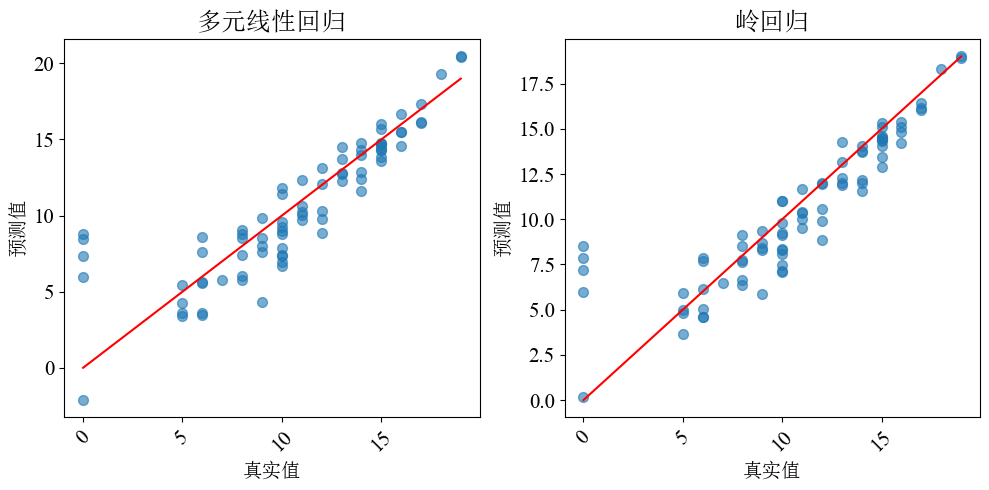

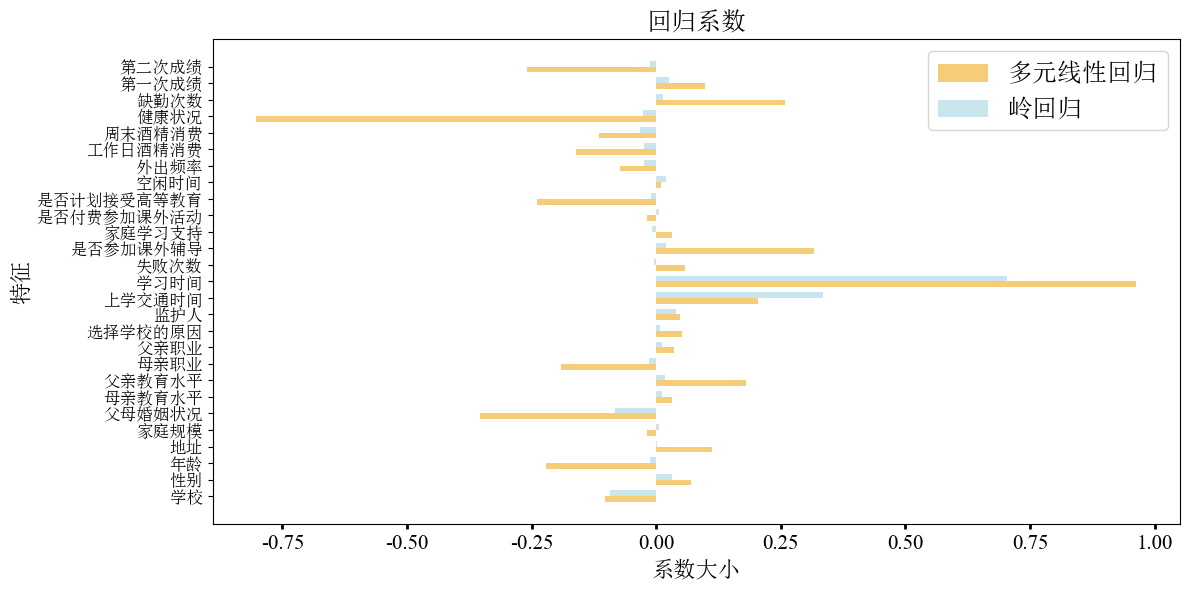

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from matplotlib.font_manager import FontProperties

# 设置支持中文字体（宋体）和英文字体（Times New Roman）
font_zh = FontProperties(fname="C:/Windows/Fonts/simsun.ttc", size=18)  # 宋体
font_en = FontProperties(fname="C:/Windows/Fonts/times.ttf", size=15)   # Times New Roman

# 读取数据
df = pd.read_csv("studentMat.csv")
df = df.dropna()

# 汉化列名
df.columns = [
    "学校", "性别", "年龄", "地址", "家庭规模", "父母婚姻状况", "母亲教育水平", "父亲教育水平",
    "母亲职业", "父亲职业", "选择学校的原因", "监护人", "上学交通时间", "学习时间", "失败次数",
    "是否参加课外辅导", "家庭学习支持", "是否付费参加课外活动", "是否参加课外活动", "是否参加幼儿园",
    "是否计划接受高等教育", "是否使用互联网", "是否有浪漫关系", "家庭关系", "空闲时间", "外出频率",
    "工作日酒精消费", "周末酒精消费", "健康状况", "缺勤次数", "第一次成绩", "第二次成绩", "最终成绩"
]

# 移除 5 个变量
variables_to_remove = ["是否参加课外活动", "是否参加幼儿园", "是否使用互联网", "是否有浪漫关系", "家庭关系"]
df = df.drop(variables_to_remove, axis=1)

# 筛选出分类列
categorical_cols = df.select_dtypes(include=['object']).columns

# 对分类列进行数值化
for col in categorical_cols:
    df[f'{col}_numeric'] = pd.factorize(df[col])[0]
    df = df.drop([col], axis=1)

# 划分训练集和测试集
X = df.drop(['最终成绩'], axis=1)
y = df['最终成绩']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 应用多元线性回归模型
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_LR = linear_model.predict(X_test)
mse_LR = mean_squared_error(y_test, y_pred_LR)
rmse_LR = np.sqrt(mse_LR)
r2_LR = r2_score(y_test, y_pred_LR)

print("多元线性回归 截距：", linear_model.intercept_)
print("多元线性回归 系数：", linear_model.coef_)
print("多元线性回归 RMSE:", rmse_LR)
print("多元线性回归 R2:", r2_LR)

# 应用岭回归模型
ridge = Ridge(alpha=1000)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("岭回归 截距：", ridge.intercept_)
print("岭回归 系数：", ridge.coef_)
print("岭回归 RMSE:", rmse_ridge)
print("岭回归 R2:", r2_ridge)

# 绘制预测值与真实值的散点图
fig, axs = plt.subplots(1, 2, figsize=(10, 5))  # 1行2列的子图布局

models = {
    '多元线性回归': y_pred_LR,
    '岭回归': y_pred_ridge
}  # 模型名称和对应的预测值

for i, (model_name, predictions) in enumerate(models.items()):
    ax = axs[i]  # 获取当前子图对象
    ax.scatter(y_test, predictions, s=50, alpha=0.6)  # 绘制散点图
    ax.plot([0, max(y_test)], [0, max(y_test)], color='red')  # 绘制对角线
    ax.set_xlabel('真实值', fontsize=14, fontproperties=font_zh)  # 设置x轴标签
    ax.set_ylabel('预测值', fontsize=14, fontproperties=font_zh)  # 设置y轴标签
    ax.set_title(model_name, fontsize=16, fontproperties=font_zh)  # 设置标题

    # 设置坐标轴刻度字体及大小
    ax.tick_params(axis='x', labelsize=12, labelrotation=45, labelcolor='black', labelbottom=True)
    ax.tick_params(axis='y', labelsize=12, labelcolor='black', labelleft=True)
    for label in ax.get_xticklabels():
        label.set_fontproperties(font_en)
    for label in ax.get_yticklabels():
        label.set_fontproperties(font_en)

# 保存和显示图表
plt.tight_layout()
plt.savefig(r"F:\zhoumian\第五章svg\图26.5.3.svg")  # 添加文件名和扩展名
plt.show()

# 绘制系数图
names = [
    "学校", "性别", "年龄", "地址", "家庭规模", "父母婚姻状况", "母亲教育水平", "父亲教育水平",
    "母亲职业", "父亲职业", "选择学校的原因", "监护人", "上学交通时间", "学习时间", "失败次数",
    "是否参加课外辅导", "家庭学习支持", "是否付费参加课外活动",
    "是否计划接受高等教育", "空闲时间", "外出频率",
    "工作日酒精消费", "周末酒精消费", "健康状况", "缺勤次数", "第一次成绩", "第二次成绩"
]
bar_positions = np.arange(len(names))  # 设定每个模型的水平位置
bar_width = 0.35  # 条形宽度

plt.figure(figsize=(12, 6))
# 绘制多元线性回归的系数
plt.barh(bar_positions - bar_width/2, linear_model.coef_, height=bar_width, color='#F5CD78', label='多元线性回归')
# 绘制岭回归的系数
plt.barh(bar_positions + bar_width/2, ridge.coef_.flatten(), height=bar_width, color='#CAE5EE', label='岭回归')
# 设置x轴标签
plt.xlabel('系数大小', fontsize=16, fontproperties=font_zh)
# 设置y轴标签
plt.ylabel('特征', fontsize=16, fontproperties=font_zh)
# 设置标题
plt.title('回归系数', fontsize=20, fontproperties=font_zh)
# 设置y轴标签
plt.yticks(bar_positions, names, fontproperties=font_zh, fontsize=12)
# 设置x轴刻度线宽度和颜色
plt.tick_params(axis='x', width=2, color='black', labelsize=14)
# 设置x轴刻度的字体属性
ax = plt.gca()
ax.xaxis.set_tick_params(labelsize=16)
for label in ax.get_xticklabels():
    label.set_fontproperties(font_en)

# 添加图例，放在图的右上角
plt.legend(loc='upper right', prop=font_zh)

# 保存和显示图表
plt.tight_layout()
plt.savefig(r"F:\zhoumian\第五章svg\图26.5.31.svg")  # 添加文件名和扩展名
plt.show()